In [6]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed\emissions_fix")

# --- Helper to load pickles ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Only files like <run>_emissions_result.pkl
PATTERN = re.compile(r"^(?P<run>.+)_emissions_result\.pkl$", re.ASCII)

def load_all_emissions_result(output_base):
    """
    Returns:
      results_by_run: dict run_name -> object loaded from pickle
      df_all: DataFrame concatenated across runs if each is a DataFrame
              otherwise None
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            p = os.path.join(root, fn)
            try:
                obj = load_pickle(p)
            except Exception as e:
                print(f"[WARN] Could not load {p}: {e}")
                continue

            results_by_run[run_name] = obj

            # If the object is a DataFrame, collect for concatenation
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                if "run_name" not in df.columns:
                    df["run_name"] = run_name
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded emissions_result for {len(results_by_run)} runs from {output_base}")
    if df_all is not None:
        print("[INFO] Concatenated DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run, df_all = load_all_emissions_result(OUTPUT_BASE)

# Example: inspect keys and one sample
print("Runs:", list(results_by_run.keys())[:10])

# If you want just the combined table:
if df_all is not None:
    display(df_all.head())


[INFO] Loaded emissions_result for 24 runs from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix
[INFO] Concatenated DataFrame shape: (39799, 41)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,overtime_cost,vehicle_cost,deliveries_per_stop,Hannover,services,is_van,is_ev,emissions,main_area_type_name,run_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139,72066,47927,18233,29694,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,132.944581,395.781895,1.432692,False,[[Service ID: service_B2B_fedex_31832_130 (Typ...,True,0,"{'drive': 46622.370183986364, 'idle': 1006.139...",Urbanized Periphery,basecase_12052025_iter150_jsprit100
1,freight_gls_31535_veh_cep_size_l_7_1,24722,64152,39430,10584,28846,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,78.965028,360.158628,1.048193,False,[[Service ID: service_B2C_gls_31535_403 (Type:...,True,0,"{'drive': 60959.71343469633, 'idle': 961.68138...",Rural with Industrial Influence,basecase_12052025_iter150_jsprit100
2,freight_ups_31311_veh_cep_size_m_7_1,25075,69743,44668,14136,30532,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,112.240878,373.377642,1.292135,False,[[Service ID: service_B2B_ups_31311_9 (Type: s...,True,0,"{'drive': 43621.87441021199, 'idle': 840.56967...",Rural with Industrial Influence,basecase_12052025_iter150_jsprit100
3,freight_ups_31832_veh_cep_size_m_7_1,25101,72941,47840,17985,29855,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,132.391889,393.511708,1.303571,False,[[Service ID: service_B2B_ups_31832_17 (Type: ...,True,0,"{'drive': 46699.331490703546, 'idle': 998.0378...",Urbanized Periphery,basecase_12052025_iter150_jsprit100
4,freight_gls_31535_veh_cep_size_m_7_5,25208,63241,38033,11392,26641,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,70.090197,328.872099,1.194805,False,[[Service ID: service_B2C_gls_31535_131 (Type:...,True,0,"{'drive': 43725.76382544209, 'idle': 712.74178...",Urbanized Periphery,basecase_12052025_iter150_jsprit100


In [7]:
df_all = df_all[df_all["vehicle_load_factor"] > 0.05]

In [2]:
# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
        
        
        
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
    
# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

In [8]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed\emissions_fix")

# --- Helper ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Match pattern: <run>_emissions_15min_long.pkl
PATTERN = re.compile(r"^(?P<run>.+)_emissions_15min_long\.pkl$", re.ASCII)

def load_emissions_15min(output_base):
    """
    Loads only *emissions_15min_long.pkl files from the directory.
    Returns a dict of run_name -> object and a combined DataFrame (if possible).
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            path = os.path.join(root, fn)
            try:
                obj = load_pickle(path)
            except Exception as e:
                print(f"[WARN] Could not load {path}: {e}")
                continue

            results_by_run[run_name] = obj

            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                df["run_name"] = run_name
                df["scenario"] = run_name.split("_")[0]
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded {len(results_by_run)} 15-min emission files from {output_base}")
    if df_all is not None:
        print("[INFO] Combined DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run_15min, df_all_15min = load_emissions_15min(OUTPUT_BASE)

# Inspect
print("Runs:", list(results_by_run_15min.keys())[:10])
if df_all_15min is not None:
    display(df_all_15min.head())


[INFO] Loaded 24 15-min emission files from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix
[INFO] Combined DataFrame shape: (166166688, 9)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,link_id,interval_15min,emissions_g,emissions_kg,emissions_t,area_type_id,area_type,run_name,scenario
0,100000,00:00,0.0,0.0,0.0,4.0,4.0,basecase_12052025_iter150_jsprit100,basecase
1,100001-192714,00:00,0.0,0.0,0.0,4.0,4.0,basecase_12052025_iter150_jsprit100,basecase
2,100003,00:00,0.0,0.0,0.0,7.0,7.0,basecase_12052025_iter150_jsprit100,basecase
3,100004,00:00,0.0,0.0,0.0,7.0,7.0,basecase_12052025_iter150_jsprit100,basecase
4,100005,00:00,0.0,0.0,0.0,7.0,7.0,basecase_12052025_iter150_jsprit100,basecase


In [9]:
import matsim
network = matsim.read_network('input/simRes/BC_500_it_no_reduction/basecase_13052025.output_network.xml.gz').as_geo().set_crs('epsg:25832')

# Create a color column based on freespeed and lane conditions
def assign_type(row):
    if row['freespeed_kmh'] <= 50:
        return 'urban'
    elif row['freespeed_kmh'] > 50 and row['permlanes'] >= 2:
        return 'highway'
    else:
        return 'rural'  # or any other default color

network['freespeed_kmh'] = network['freespeed'] * 3.6
network['road_type'] = network.apply(assign_type, axis=1)

link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']
link_type = network[['link_id', 'road_type']].set_index('link_id').to_dict()['road_type']

Selected run: basecase_12052025_iter150_jsprit100
Aggregate emissions per link to one day
Prepare links
Build Hex
Join
Emissiosn per Hex


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\4061898181.py:153: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  gpd.GeoSeries([links_gdf.union_all().buffer(0)], crs=links_gdf.crs).boundary.plot(ax=ax, linewidth=0.8)


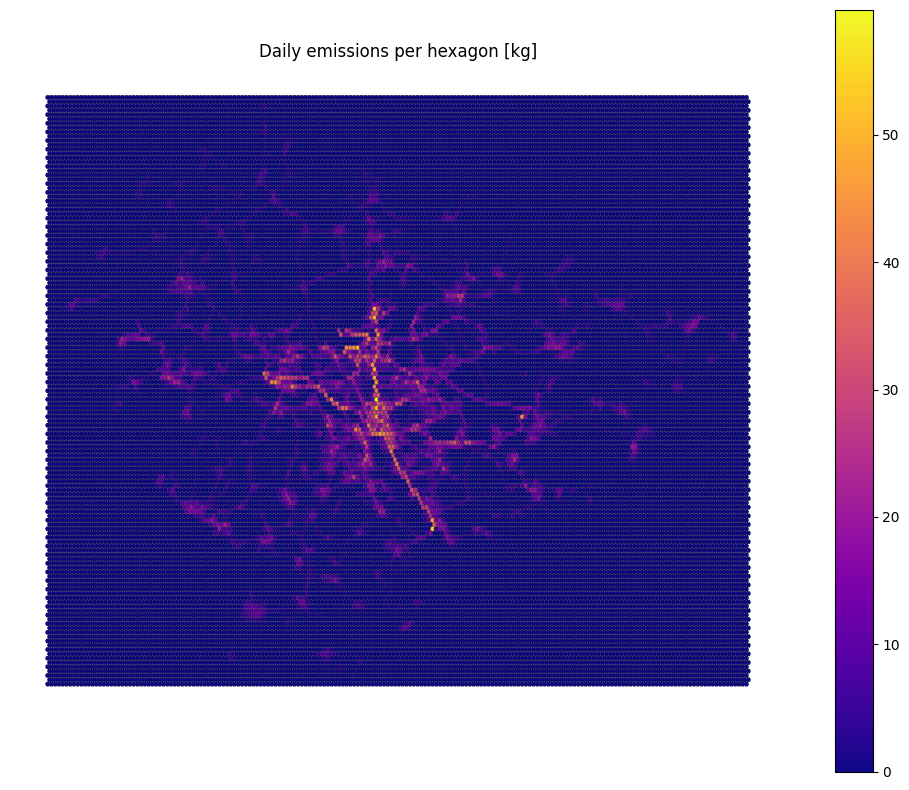

In [10]:
# Daily emissions per hexagon from one 15 min scenario
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Preconditions in memory:
# - df_all_15min: DataFrame with columns at least ['run_name','link_id','emissions_g']
# - network: GeoDataFrame with ['link_id','geometry'] in a metric CRS like EPSG:25832

def pick_first_run(df_all_15min: pd.DataFrame, prefer_scenario_prefix: bool = True) -> str:
    if 'run_name' not in df_all_15min.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all_15min.")
    work = df_all_15min
    if 'scenario' not in work.columns:
        work = work.copy()
        work['scenario'] = work['run_name'].astype(str).str.split('_').str[0]
    if prefer_scenario_prefix:
        first_scen = sorted(work['scenario'].dropna().unique().tolist())[0]
        cand_runs = work.loc[work['scenario'] == first_scen, 'run_name'].dropna().unique().tolist()
        if not cand_runs:
            raise RuntimeError("No runs found for the first scenario.")
        return sorted(cand_runs)[0]
    return sorted(work['run_name'].dropna().unique().tolist())[0]

# 0) Pick exactly one run and build emissions_15min_long for that run
run_name_one = pick_first_run(df_all_15min, prefer_scenario_prefix=True)
print("Selected run:", run_name_one)

need = ['link_id','emissions_g','run_name']
missing = [c for c in need if c not in df_all_15min.columns]
if missing:
    raise RuntimeError(f"Missing columns in df_all_15min: {missing}")

emissions_15min_long = (
    df_all_15min.loc[df_all_15min['run_name'] == run_name_one, need]
    .copy()
)
emissions_15min_long['emissions_g'] = pd.to_numeric(emissions_15min_long['emissions_g'], errors='coerce').fillna(0.0)

print("Aggregate emissions per link to one day")
# 1) Aggregate emissions per link to one day
emissions_day = (
    emissions_15min_long.groupby('link_id', as_index=False)['emissions_g']
    .sum().rename(columns={'emissions_g': 'emissions_g_day'})
)

print("Prepare links")
# 2) Prepare links GeoDataFrame
links_gdf = (
    network[['link_id', 'geometry']]
    .drop_duplicates(subset=['link_id'])
    .merge(emissions_day, on='link_id', how='left')
    .fillna({'emissions_g_day': 0.0})
)

# Filter out zero links early
EPS = 1e-12
links_gdf = links_gdf[links_gdf['emissions_g_day'] > EPS]
if links_gdf.empty:
    raise ValueError("No links with positive emissions.")

print("Build Hex")
# 3) Build a 10 km flat topped hex grid covering the links extent
hex_size = 500.0  # flat to flat width
r = hex_size / 2.0
dx = 3.0 * r / 2.0                # column spacing for flat topped hexes
dy = np.sqrt(3.0) * r             # row spacing for flat topped hexes  <-- fixed

minx, miny, maxx, maxy = links_gdf.total_bounds
pad = hex_size
minx, miny, maxx, maxy = minx - pad, miny - pad, maxx + pad, maxy + pad

def hex_polygon(cx, cy, rad):
    angles = np.deg2rad([0, 60, 120, 180, 240, 300])  # flat topped
    verts = [(cx + rad * np.cos(a), cy + rad * np.sin(a)) for a in angles]
    return Polygon(verts)

hexes = []
hex_ids = []
j = 0
row = 0
y = miny
while y <= maxy + 1e-6:
    x_offset = 0.0 if (row % 2 == 0) else dx / 2.0
    x = minx
    while x <= maxx + 1e-6:
        cx = x + x_offset
        poly = hex_polygon(cx, y, r)
        hexes.append(poly)
        hex_ids.append(j)
        j += 1
        x += dx
    y += dy
    row += 1

hex_gdf = gpd.GeoDataFrame({'hex_id': hex_ids}, geometry=hexes, crs=links_gdf.crs)
hex_gdf['cx'] = hex_gdf.geometry.centroid.x.astype(float)
hex_gdf['cy'] = hex_gdf.geometry.centroid.y.astype(float)

# 4) Length weighted allocation of link emissions to hexes
# compute link length
links_gdf = links_gdf.copy()
links_gdf['link_len'] = links_gdf.geometry.length.astype(float)
links_gdf = links_gdf[links_gdf['link_len'] > 0.0].copy()

print("Join")
# prefilter candidate pairs
pairs = gpd.sjoin(
    links_gdf[['link_id','geometry','emissions_g_day','link_len']],
    hex_gdf[['hex_id','geometry']],
    how='inner',
    predicate='intersects'
).rename(columns={'geometry':'link_geom'})

pairs = pairs.merge(
    hex_gdf[['hex_id','geometry']].rename(columns={'geometry':'hex_geom'}),
    on='hex_id', how='left'
)

# compute intersection length inside each hex
seg_len = []
for lg, hg in zip(pairs['link_geom'].array, pairs['hex_geom'].array):
    try:
        inter = lg.intersection(hg)
        seg_len.append(float(inter.length) if inter and not inter.is_empty else 0.0)
    except Exception:
        seg_len.append(0.0)

pairs['seg_len'] = np.asarray(seg_len, dtype=float)
pairs = pairs[pairs['seg_len'] > 0.0].copy()
if pairs.empty:
    raise ValueError("No intersections after spatial join. Check CRS and hex size.")

# allocate by length share
pairs['weight'] = (pairs['seg_len'] / pairs['link_len']).clip(0.0, 1.0)
pairs['emissions_g_alloc'] = pairs['emissions_g_day'] * pairs['weight']

print("Emissiosn per Hex")
# 5) Sum emissions per hex (kg per day)
em_hex = pairs.groupby('hex_id', as_index=False)['emissions_g_alloc'].sum()
em_hex['emissions_kg_day'] = em_hex['emissions_g_alloc'] / 1000.0

hex_emit = hex_gdf.merge(
    em_hex[['hex_id','emissions_kg_day']],
    on='hex_id', how='left'
).fillna({'emissions_kg_day': 0.0})

# 6) Simple plot
fig, ax = plt.subplots(figsize=(10, 8))
hex_emit.plot(column='emissions_kg_day', linewidth=0.2, edgecolor='black', legend=True, ax=ax, cmap = "plasma")
gpd.GeoSeries([links_gdf.union_all().buffer(0)], crs=links_gdf.crs).boundary.plot(ax=ax, linewidth=0.8)
ax.set_title("Daily emissions per hexagon [kg]")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# optional: result for reuse
hex_emissions_gdf = hex_emit.copy()


[INFO] scenarios detected: ['basecase', 'batchhigh', 'batchmedium', 'batchmoderate']
[INFO] baseline: basecase
[INFO] aggregate week per link for basecase
[INFO] aggregate week per link for batchhigh
[INFO] aggregate week per link for batchmedium
[INFO] aggregate week per link for batchmoderate
[INFO] build shared hex grid from union of all emitting links
[INFO] allocate to hex for basecase
[INFO] sjoin links x hex
[INFO] compute segment lengths
[INFO] write C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_hex\basecase_weekly_hex.parquet
[INFO] write C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_hex\basecase_weekly_hex.gpkg
[INFO] allocate to hex for batchhigh
[INFO] sjoin links x hex
[INFO] compute segment lengths
[INFO] write C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_hex\batchhigh_weekly_hex

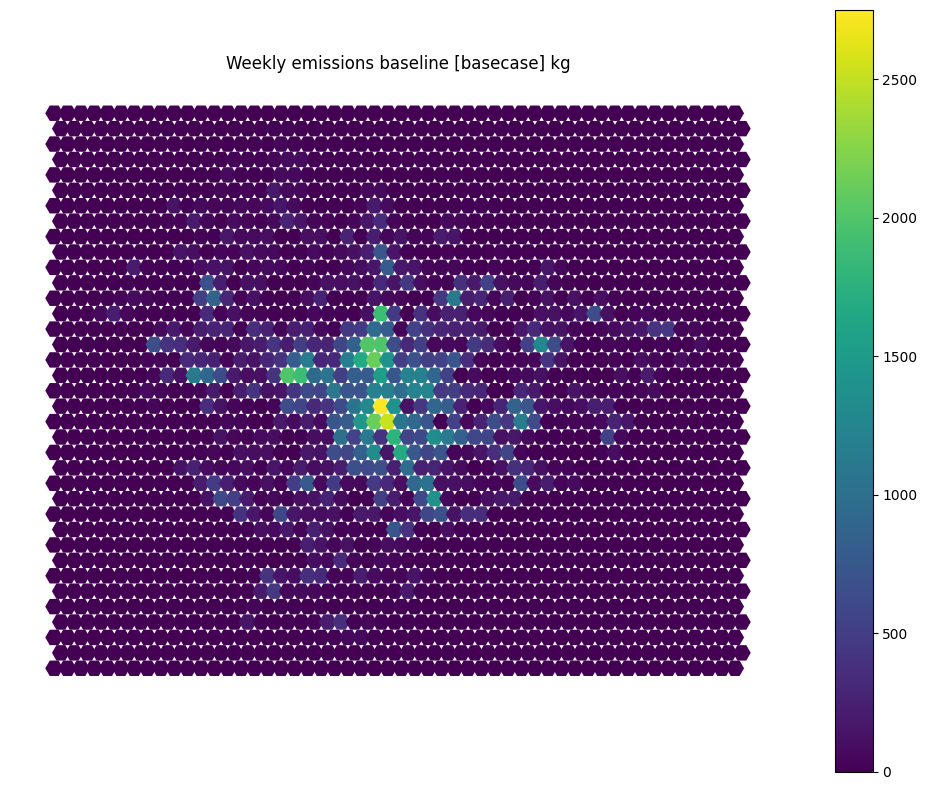

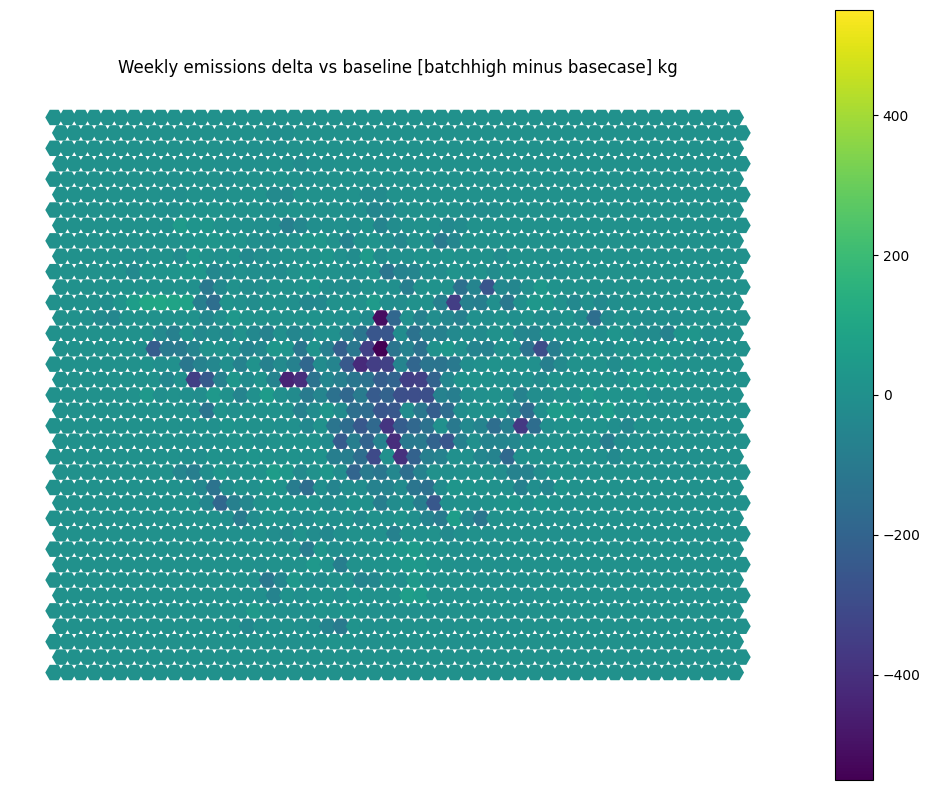

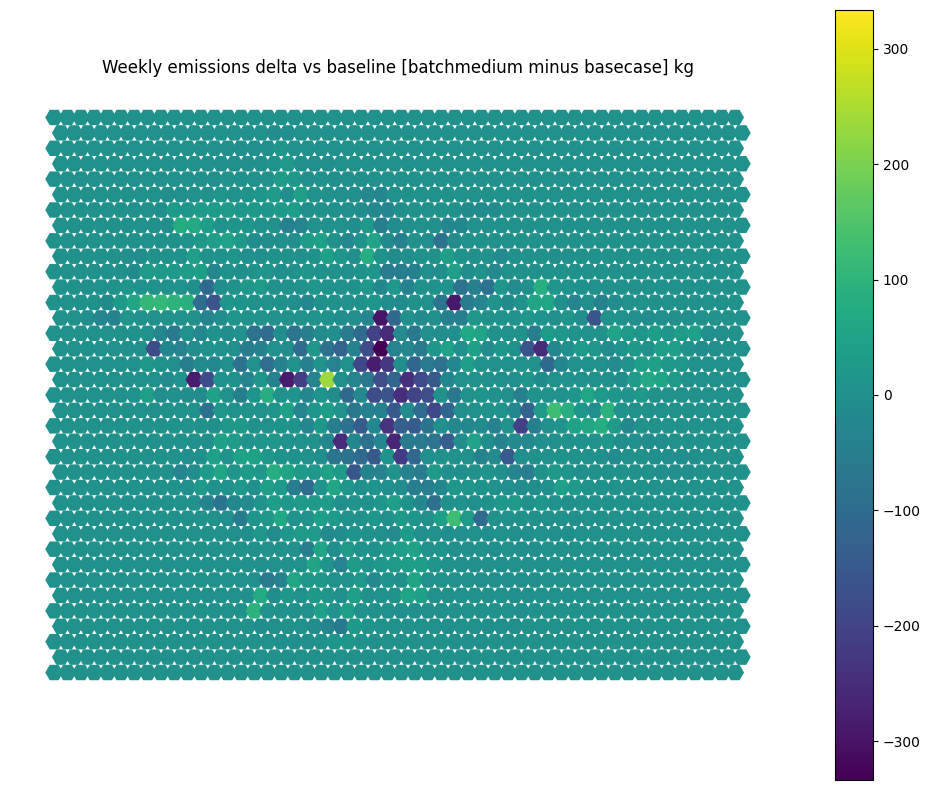

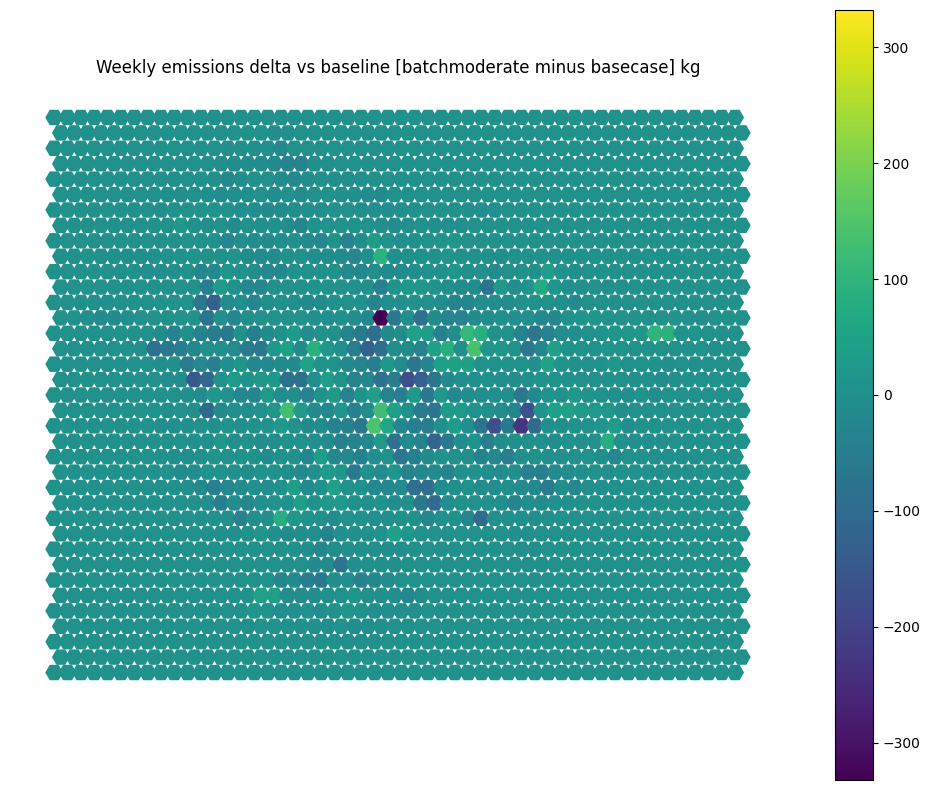

In [11]:
# Weekly emissions on a shared hex grid using your working sjoin + intersection approach

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Required in memory:
# - df_all_15min with columns ['scenario','run_name','link_id','emissions_g']
# - network: GeoDataFrame with ['link_id','geometry'] in metric CRS, e.g. EPSG:25832
# - OUTPUT_BASE

# Config
WEEKLY_DIR = os.path.join(OUTPUT_BASE, "weekly_hex")
os.makedirs(WEEKLY_DIR, exist_ok=True)
HEX_SIZE_M = 2000.0     # use your working size
EPS = 1e-12

def build_flat_topped_hexgrid_from_bounds(bounds, hex_size_m, crs):
    minx, miny, maxx, maxy = bounds
    pad = hex_size_m
    minx, miny, maxx, maxy = minx - pad, miny - pad, maxx + pad, maxy + pad

    r = hex_size_m / 2.0
    dx = 3.0 * r / 2.0          # column spacing for flat topped
    dy = np.sqrt(3.0) * r       # row spacing for flat topped

    def hex_polygon(cx, cy, rad):
        angles = np.deg2rad([0, 60, 120, 180, 240, 300])
        verts = [(cx + rad * np.cos(a), cy + rad * np.sin(a)) for a in angles]
        return Polygon(verts)

    hexes = []
    hex_ids = []
    j = 0
    row = 0
    y = miny
    while y <= maxy + 1e-6:
        x_offset = 0.0 if (row % 2 == 0) else dx / 2.0
        x = minx
        while x <= maxx + 1e-6:
            cx = x + x_offset
            hexes.append(hex_polygon(cx, y, r))
            hex_ids.append(j)
            j += 1
            x += dx
        y += dy
        row += 1

    g = gpd.GeoDataFrame({"hex_id": hex_ids}, geometry=hexes, crs=crs)
    g["cx"] = g.geometry.centroid.x.astype(float)
    g["cy"] = g.geometry.centroid.y.astype(float)
    return g

def allocate_to_hex_by_length(links_gdf, hex_gdf):
    # exactly your working method: sjoin candidates, compute intersection length, weight by length share
    work_links = links_gdf.copy()
    work_links["link_len"] = work_links.geometry.length.astype(float)
    work_links = work_links[work_links["link_len"] > 0.0].copy()

    print("[INFO] sjoin links x hex")
    pairs = gpd.sjoin(
        work_links[["link_id","geometry","emissions_g_week","link_len"]],
        hex_gdf[["hex_id","geometry"]],
        how="inner",
        predicate="intersects"
    ).rename(columns={"geometry":"link_geom"})

    pairs = pairs.merge(
        hex_gdf[["hex_id","geometry"]].rename(columns={"geometry":"hex_geom"}),
        on="hex_id", how="left"
    )

    print("[INFO] compute segment lengths")
    seg_len = []
    for lg, hg in zip(pairs["link_geom"].array, pairs["hex_geom"].array):
        try:
            inter = lg.intersection(hg)
            seg_len.append(float(inter.length) if inter and not inter.is_empty else 0.0)
        except Exception:
            seg_len.append(0.0)

    pairs["seg_len"] = np.asarray(seg_len, dtype=float)
    pairs = pairs[pairs["seg_len"] > 0.0].copy()
    if pairs.empty:
        print("[WARN] sjoin produced no positive segments")
        # return zeros on the same grid to keep shapes consistent
        zero = hex_gdf.copy()
        zero["emissions_kg_week"] = 0.0
        return zero

    pairs["weight"] = (pairs["seg_len"] / pairs["link_len"]).clip(0.0, 1.0)
    pairs["emissions_g_alloc"] = pairs["emissions_g_week"] * pairs["weight"]

    em_hex = pairs.groupby("hex_id", as_index=False)["emissions_g_alloc"].sum()
    em_hex["emissions_kg_week"] = em_hex["emissions_g_alloc"] / 1000.0

    hex_emit = hex_gdf.merge(
        em_hex[["hex_id","emissions_kg_week"]],
        on="hex_id", how="left"
    ).fillna({"emissions_kg_week": 0.0})

    return hex_emit

# 1) Weekly per link for all scenarios
print("[INFO] scenarios detected:", sorted(df_all_15min["scenario"].dropna().unique().tolist()))
scenarios = sorted(df_all_15min["scenario"].dropna().unique().tolist())
BASE = next((s for s in scenarios if s.lower() in {"basecase","baseline","base","ref","reference","statusquo","status_quo","basis","default"}), scenarios[0])
print("[INFO] baseline:", BASE)

weekly_per_link = {}
links_union_list = []

for scen in scenarios:
    print(f"[INFO] aggregate week per link for {scen}")
    work = df_all_15min.loc[df_all_15min["scenario"] == scen, ["link_id","emissions_g"]].copy()
    work["emissions_g"] = pd.to_numeric(work["emissions_g"], errors="coerce").fillna(0.0)
    week_per_link = work.groupby("link_id", as_index=False)["emissions_g"].sum().rename(columns={"emissions_g":"emissions_g_week"})
    # join geometry
    links = (
        network[["link_id","geometry"]]
        .drop_duplicates(subset=["link_id"])
        .merge(week_per_link, on="link_id", how="left")
        .fillna({"emissions_g_week": 0.0})
    )
    links = links[links["emissions_g_week"] > EPS].copy()
    weekly_per_link[scen] = links
    if not links.empty:
        links_union_list.append(links)

if not links_union_list:
    raise RuntimeError("No scenario has positive weekly emissions after join. Check inputs.")

# 2) Build shared hex grid from union of all emitting links
print("[INFO] build shared hex grid from union of all emitting links")
links_all = pd.concat(links_union_list, ignore_index=True)
bounds = links_all.total_bounds
hex_gdf = build_flat_topped_hexgrid_from_bounds(bounds, HEX_SIZE_M, network.crs)

# 3) Allocate per scenario on the shared grid and save
weekly_hex = {}

for scen in scenarios:
    print(f"[INFO] allocate to hex for {scen}")
    links = weekly_per_link[scen]
    if links.empty:
        print(f"[WARN] {scen} empty after weekly sum. Writing zeros.")
        hex_emit = hex_gdf.copy()
        hex_emit["emissions_kg_week"] = 0.0
    else:
        hex_emit = allocate_to_hex_by_length(links, hex_gdf)

    out_base = os.path.join(WEEKLY_DIR, f"{scen}_weekly_hex")
    print(f"[INFO] write {out_base}.parquet")
    hex_emit.to_parquet(out_base + ".parquet", index=False)
    print(f"[INFO] write {out_base}.gpkg")
    hex_emit.to_file(out_base + ".gpkg", layer="hex", driver="GPKG")

    weekly_hex[scen] = hex_emit

# 4) Deltas vs baseline on the same grid
base_hex = weekly_hex[BASE][["hex_id","emissions_kg_week","geometry"]].rename(columns={"emissions_kg_week":"emissions_kg_week_base"})

for scen in scenarios:
    if scen == BASE:
        continue
    print(f"[INFO] build delta {scen} vs {BASE}")
    comp = weekly_hex[scen][["hex_id","emissions_kg_week","geometry"]].rename(columns={"emissions_kg_week":"emissions_kg_week_scen"})
    comp = comp.merge(base_hex.drop(columns=["geometry"]), on="hex_id", how="left")
    comp["delta_kg"] = comp["emissions_kg_week_scen"] - comp["emissions_kg_week_base"]
    comp["delta_pct"] = np.where(
        comp["emissions_kg_week_base"] > 0.0,
        100.0 * comp["delta_kg"] / comp["emissions_kg_week_base"],
        np.nan
    )
    comp = gpd.GeoDataFrame(comp, geometry="geometry", crs=network.crs)
    out_base = os.path.join(WEEKLY_DIR, f"{scen}_vs_{BASE}_weekly_hex_delta")
    print(f"[INFO] write {out_base}.parquet")
    comp.to_parquet(out_base + ".parquet", index=False)
    print(f"[INFO] write {out_base}.gpkg")
    comp.to_file(out_base + ".gpkg", layer="hex", driver="GPKG")
    weekly_hex[scen + "_delta"] = comp

print("[INFO] all weekly layers written")

# 5) Quick plots identical style to your working daily map

# Baseline
fig, ax = plt.subplots(figsize=(10, 8))
weekly_hex[BASE].plot(
    column="emissions_kg_week",
    ax=ax,
    linewidth=0,
    edgecolor="none",
    legend=True
)
ax.set_title(f"Weekly emissions baseline [{BASE}] kg")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Deltas
for scen in scenarios:
    if scen == BASE:
        continue
    comp = weekly_hex[scen + "_delta"]
    vmax = float(np.nanmax(np.abs(comp["delta_kg"].values))) if len(comp) else 1.0
    vmin = -vmax
    fig, ax = plt.subplots(figsize=(10, 8))
    comp.plot(
        column="delta_kg",
        ax=ax,
        linewidth=0,
        edgecolor="none",
        legend=True,
        vmin=vmin, vmax=vmax
    )
    ax.set_title(f"Weekly emissions delta vs baseline [{scen} minus {BASE}] kg")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [12]:
# Summaries for weekly totals and deltas

import os
import pandas as pd
import numpy as np

# Preconditions:
# - weekly_hex: dict scenario -> GeoDataFrame with 'emissions_kg_week'
# - scenarios: list of scenario names
# - BASE: baseline scenario string
# - WEEKLY_DIR: output directory

print("[INFO] build weekly totals table")
rows = []
for scen in scenarios:
    g = weekly_hex.get(scen, None)
    if g is None or g.empty:
        total = 0.0
        nz = 0
    else:
        total = float(np.nansum(g["emissions_kg_week"].to_numpy()))
        nz = int(np.sum((g["emissions_kg_week"] > 0).to_numpy()))
    rows.append({"scenario": scen, "total_kg_week": total, "hex_count_positive": nz})

totals_df = pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)
print(totals_df)

totals_csv = os.path.join(WEEKLY_DIR, "weekly_totals_by_scenario.csv")
totals_df.to_csv(totals_csv, index=False)
print(f"[INFO] wrote {totals_csv}")

# Deltas vs baseline
print("[INFO] build deltas vs baseline table")
base_total = float(totals_df.loc[totals_df["scenario"] == BASE, "total_kg_week"].values[0]) if (BASE in totals_df["scenario"].values) else 0.0

delta_rows = []
for scen in scenarios:
    if scen == BASE:
        continue
    comp = weekly_hex.get(scen + "_delta", None)
    if comp is None or comp.empty:
        delta_kg = 0.0
    else:
        delta_kg = float(np.nansum(comp["delta_kg"].to_numpy()))
    delta_pct = (100.0 * delta_kg / base_total) if base_total > 0.0 else np.nan
    delta_rows.append({
        "scenario": scen,
        "delta_kg_vs_base": delta_kg,
        "delta_pct_vs_base": delta_pct
    })

deltas_df = pd.DataFrame(delta_rows).sort_values("scenario").reset_index(drop=True)
print(deltas_df)

deltas_csv = os.path.join(WEEKLY_DIR, f"weekly_deltas_vs_{BASE}.csv")
deltas_df.to_csv(deltas_csv, index=False)
print(f"[INFO] wrote {deltas_csv}")

# Optional: combined table for quick viewing
summary_df = totals_df.merge(
    deltas_df, on="scenario", how="left"
).sort_values("scenario").reset_index(drop=True)

print("\n[INFO] summary table")
print(summary_df)

summary_csv = os.path.join(WEEKLY_DIR, f"weekly_summary_with_deltas_vs_{BASE}.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"[INFO] wrote {summary_csv}")


[INFO] build weekly totals table
        scenario  total_kg_week  hex_count_positive
0       basecase  179910.165116                 838
1      batchhigh  152681.524705                 881
2    batchmedium  171683.913106                 857
3  batchmoderate  174217.300452                 846
[INFO] wrote C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_hex\weekly_totals_by_scenario.csv
[INFO] build deltas vs baseline table
        scenario  delta_kg_vs_base  delta_pct_vs_base
0      batchhigh     -27228.640410         -15.134576
1    batchmedium      -8226.252010          -4.572422
2  batchmoderate      -5692.864664          -3.164282
[INFO] wrote C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_hex\weekly_deltas_vs_basecase.csv

[INFO] summary table
        scenario  total_kg_week  hex_count_positive  delta_kg_vs_base  \
0       basecase  179910.165116           

In [13]:
# Build a clean total column from 'emissions' which may be a dict or a scalar
mask_dict = df_all["emissions"].apply(lambda x: isinstance(x, dict))

df_all["emissions_total"] = 0.0

# Case 1 dict with key 'total'
df_all.loc[mask_dict, "emissions_total"] = (
    df_all.loc[mask_dict, "emissions"]
    .apply(lambda d: float(d.get("total", 0.0)))
    .astype(float)
)

# Case 2 scalar or other types
df_all.loc[~mask_dict, "emissions_total"] = (
    pd.to_numeric(df_all.loc[~mask_dict, "emissions"], errors="coerce")
    .fillna(0.0)
    .astype(float)
)


In [14]:
import re
import numpy as np
import pandas as pd

# ---------- helpers ----------

def detect_concept(run_name: str) -> str:
    s = str(run_name).lower()
    if "batchmoderate" in s:
        return "batchmoderate"
    if "batchmedium" in s:
        return "batchmedium"
    if "batchhigh" in s:
        return "batchhigh"
    if "base" in s or "baseline" in s or "basecase" in s:
        return "baseline"
    return "other"

def extract_date_token(run_name: str) -> str | None:
    m = re.search(r"(\d{8})", str(run_name))
    return m.group(1) if m else None

def pick_tour_km_column(df: pd.DataFrame) -> str:
    # Try common variants
    candidates = ["Tour_km", "tour_km", "tourkm", "total_tour_km", "Distance per Tour (km)"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError("No tour km column found. Please add one of: " + ", ".join(candidates))

def normalize_emissions_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build numeric columns: emissions_drive, emissions_idle, emissions_cold, emissions_total.
    Accepts dicts like {'drive': x, 'idle': y, 'cold': z, 'total': t, 'shares': {...}}
    or scalars (interpreted as total).
    """
    out = df.copy()
    out["emissions_drive"] = 0.0
    out["emissions_idle"] = 0.0
    out["emissions_cold"] = 0.0
    out["emissions_total"] = 0.0

    is_dict = out["emissions"].apply(lambda x: isinstance(x, dict))

    # dict rows
    dct = out.loc[is_dict, "emissions"]
    out.loc[is_dict, "emissions_drive"] = dct.apply(lambda d: float(d.get("drive", 0.0)))
    out.loc[is_dict, "emissions_idle"]  = dct.apply(lambda d: float(d.get("idle", 0.0)))
    out.loc[is_dict, "emissions_cold"]  = dct.apply(lambda d: float(d.get("cold", 0.0)))
    out.loc[is_dict, "emissions_total"] = dct.apply(lambda d: float(d.get("total", 0.0) if "total" in d else d.get("drive",0.0)+d.get("idle",0.0)+d.get("cold",0.0)))

    # scalar rows
    if (~is_dict).any():
        out.loc[~is_dict, "emissions_total"] = pd.to_numeric(out.loc[~is_dict, "emissions"], errors="coerce").fillna(0.0).astype(float)

    return out

# ---------- main aggregation ----------

df = df_all.copy()

# Concept and date token
df["concept"] = df["run_name"].map(detect_concept)
df["date_token"] = df["run_name"].map(extract_date_token)

# Keep only relevant concepts
wanted = {"baseline", "batchmoderate", "batchmedium", "batchhigh"}
df = df[df["concept"].isin(wanted)].copy()

# Tour km column
tour_col = pick_tour_km_column(df)
df[tour_col] = pd.to_numeric(df[tour_col], errors="coerce").fillna(0.0)

# Emissions columns
df = normalize_emissions_columns(df)

# EV share per concept:
# Prefer unique vehicles per run to avoid multiple rows per vehicle.
if "vehicle_id" in df.columns:
    veh = df[["run_name", "concept", "vehicle_id", "is_ev"]].drop_duplicates()
    veh["is_ev"] = pd.to_numeric(veh["is_ev"], errors="coerce").fillna(0).astype(int)
    ev_by_run = veh.groupby(["concept", "run_name"], dropna=False)["is_ev"].agg(ev_sum="sum", n="count").reset_index()
else:
    # Fallback: use row-level mean within run_name
    tmp = df.groupby(["concept", "run_name"], dropna=False)["is_ev"].mean(numeric_only=True).reset_index(name="ev_mean")
    tmp["ev_sum"] = tmp["ev_mean"]  # will be used only for ratio
    tmp["n"] = 1
    ev_by_run = tmp.rename(columns={"ev_mean": "is_ev"})  # not used directly

# Aggregate emissions and tour km per run and day
per_run_day = (
    df.groupby(["concept", "run_name", "date_token"], dropna=False)
      .agg(
          tour_km_sum=(tour_col, "sum"),
          em_drive=("emissions_drive", "sum"),
          em_idle=("emissions_idle", "sum"),
          em_cold=("emissions_cold", "sum"),
          em_total=("emissions_total", "sum")
      ).reset_index()
)

# Merge EV info to per_run_day at run level
per_run = per_run_day.groupby(["concept", "run_name"], dropna=False).agg(
    tour_km_sum=("tour_km_sum", "sum"),
    em_drive=("em_drive", "sum"),
    em_idle=("em_idle", "sum"),
    em_cold=("em_cold", "sum"),
    em_total=("em_total", "sum"),
    days=("date_token", "nunique")
).reset_index()

# EV share per run_name
if "vehicle_id" in df.columns:
    ev_share = ev_by_run.copy()
    ev_share["ev_share"] = ev_share["ev_sum"] / ev_share["n"]
    ev_share = ev_share[["concept", "run_name", "ev_share"]]
else:
    # Fallback: approximate from row-level mean
    ev_share = df.groupby(["concept", "run_name"], dropna=False)["is_ev"].mean(numeric_only=True).reset_index(name="ev_share")

per_run = per_run.merge(ev_share, on=["concept", "run_name"], how="left")

# Concept rollup over six days
concept_agg = (
    per_run.groupby("concept", dropna=False)
      .agg(
          days=("days", "sum"),  # should be 6 if each run has 1 day and there is one run per day
          tour_km_6d=("tour_km_sum", "sum"),
          em_drive_6d=("em_drive", "sum"),
          em_idle_6d=("em_idle", "sum"),
          em_cold_6d=("em_cold", "sum"),
          em_total_6d=("em_total", "sum"),
          ev_share_avg=("ev_share", "mean")
      ).reset_index()
)

# Shares of components relative to total
eps = 1e-12
concept_agg["share_idle"] = concept_agg["em_idle_6d"] / np.maximum(concept_agg["em_total_6d"], eps)
concept_agg["share_cold"] = concept_agg["em_cold_6d"] / np.maximum(concept_agg["em_total_6d"], eps)
concept_agg["share_drive"] = concept_agg["em_drive_6d"] / np.maximum(concept_agg["em_total_6d"], eps)

# Baseline comparison for emissions and tour km
base = concept_agg.loc[concept_agg["concept"] == "baseline"]
if not base.empty:
    bt = float(base["em_total_6d"].iloc[0])
    bkm = float(base["tour_km_6d"].iloc[0])
    concept_agg["pct_vs_baseline_em_total"] = 100.0 * (concept_agg["em_total_6d"] - bt) / bt if bt else np.nan
    concept_agg["pct_vs_baseline_tour_km"] = 100.0 * (concept_agg["tour_km_6d"] - bkm) / bkm if bkm else np.nan

# Optional pretty print
order = ["baseline", "batchmoderate", "batchmedium", "batchhigh"]
concept_agg["order"] = concept_agg["concept"].map({k: i for i, k in enumerate(order)})
concept_agg = concept_agg.sort_values("order").drop(columns=["order"])

cols_show = [
    "concept", "days",
    "tour_km_6d",
    "em_drive_6d", "em_idle_6d", "em_cold_6d", "em_total_6d",
    "share_drive", "share_idle", "share_cold",
    "ev_share_avg",
    "pct_vs_baseline_em_total", "pct_vs_baseline_tour_km"
]

print(concept_agg[cols_show].to_string(index=False))


      concept  days    tour_km_6d  em_drive_6d   em_idle_6d  em_cold_6d  em_total_6d  share_drive  share_idle  share_cold  ev_share_avg  pct_vs_baseline_em_total  pct_vs_baseline_tour_km
     baseline     6 927238.192153 1.748435e+08 4.575402e+06    387830.0 1.798067e+08     0.972397    0.025446    0.002157      0.201648                  0.000000                 0.000000
batchmoderate     6 902140.653500 1.693918e+08 4.418076e+06    422164.0 1.742320e+08     0.972220    0.025357    0.002423      0.203656                 -3.100402                -2.706698
  batchmedium     6 942631.897607 1.674250e+08 3.766213e+06    516778.0 1.717080e+08     0.975057    0.021934    0.003010      0.207108                 -4.504111                 1.660167
    batchhigh     6 838779.965191 1.485248e+08 3.645646e+06    548094.0 1.527186e+08     0.972539    0.023872    0.003589      0.207109                -15.065160                -9.539968


In [15]:
import re
import numpy as np
import pandas as pd

# ---------- helpers ----------

def detect_concept(run_name: str) -> str:
    s = str(run_name).lower()
    if "batchmoderate" in s:
        return "batchmoderate"
    if "batchmedium" in s:
        return "batchmedium"
    if "batchhigh" in s:
        return "batchhigh"
    if "base" in s or "baseline" in s or "basecase" in s:
        return "baseline"
    return "other"

def pick_tour_km_column(df: pd.DataFrame) -> str:
    candidates = ["Tour_km", "tour_km", "tourkm", "total_tour_km", "Distance per Tour (km)"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError("No tour km column found. Provide one of: " + ", ".join(candidates))

def normalize_emissions_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build numeric columns for drive, idle, cold, total from a mixed 'emissions' column.
    Accepts dicts like {'drive': x, 'idle': y, 'cold': z, 'total': t, 'shares': {...}} or scalars for total.
    Units are preserved. If your totals are in grams, results will be grams per km.
    """
    out = df.copy()
    out["emissions_drive"] = 0.0
    out["emissions_idle"] = 0.0
    out["emissions_cold"] = 0.0
    out["emissions_total"] = 0.0

    is_dict = out["emissions"].apply(lambda x: isinstance(x, dict))

    # dict rows
    if is_dict.any():
        dct = out.loc[is_dict, "emissions"]
        out.loc[is_dict, "emissions_drive"] = dct.apply(lambda d: float(d.get("drive", 0.0)))
        out.loc[is_dict, "emissions_idle"]  = dct.apply(lambda d: float(d.get("idle", 0.0)))
        out.loc[is_dict, "emissions_cold"]  = dct.apply(lambda d: float(d.get("cold", 0.0)))
        out.loc[is_dict, "emissions_total"] = dct.apply(
            lambda d: float(d.get("total", d.get("drive", 0.0) + d.get("idle", 0.0) + d.get("cold", 0.0)))
        )

    # scalar rows interpreted as total
    if (~is_dict).any():
        out.loc[~is_dict, "emissions_total"] = (
            pd.to_numeric(out.loc[~is_dict, "emissions"], errors="coerce").fillna(0.0).astype(float)
        )

    return out

# ---------- main ----------

df = df_all.copy()
df["concept"] = df["run_name"].map(detect_concept)

# keep only the four concepts
wanted = {"baseline", "batchmoderate", "batchmedium", "batchhigh"}
df = df[df["concept"].isin(wanted)].copy()

# normalize emissions and tour km
df = normalize_emissions_columns(df)
tour_col = pick_tour_km_column(df)
df[tour_col] = pd.to_numeric(df[tour_col], errors="coerce").fillna(0.0)

# defensive EV flag
if "is_ev" not in df.columns:
    df["is_ev"] = 0
df["is_ev"] = pd.to_numeric(df["is_ev"], errors="coerce").fillna(0).astype(int)

# Aggregate per vehicle and concept across all days:
per_vehicle = (
    df.groupby(["concept", "vehicle_id"], dropna=False)
      .agg(
          km_sum=(tour_col, "sum"),
          em_drive_sum=("emissions_drive", "sum"),
          em_idle_sum=("emissions_idle", "sum"),
          em_cold_sum=("emissions_cold", "sum"),
          em_total_sum=("emissions_total", "sum"),
          ev_flag=("is_ev", "max")  # treat vehicle as EV if it was EV at least once
      ).reset_index()
)

# Compute per-vehicle intensities. Avoid division by zero.
eps = 1e-12
per_vehicle["gpkm_total"] = per_vehicle["em_total_sum"] / np.maximum(per_vehicle["km_sum"], eps)
per_vehicle["gpkm_drive"] = per_vehicle["em_drive_sum"] / np.maximum(per_vehicle["km_sum"], eps)
per_vehicle["gpkm_idle"]  = per_vehicle["em_idle_sum"]  / np.maximum(per_vehicle["km_sum"], eps)
per_vehicle["gpkm_cold"]  = per_vehicle["em_cold_sum"]  / np.maximum(per_vehicle["km_sum"], eps)

# Average per concept across vehicles
avg_by_concept = (
    per_vehicle.groupby("concept", dropna=False)[["gpkm_total", "gpkm_drive", "gpkm_idle", "gpkm_cold"]]
    .mean()
    .reset_index()
)

# Optional: median for robustness
median_by_concept = (
    per_vehicle.groupby("concept", dropna=False)[["gpkm_total", "gpkm_drive", "gpkm_idle", "gpkm_cold"]]
    .median()
    .add_prefix("median_")
    .reset_index()
    .rename(columns={"median_concept": "concept"})
)

# EV vs non EV breakdown per concept
avg_by_concept_ev_split = (
    per_vehicle.groupby(["concept", "ev_flag"], dropna=False)[["gpkm_total", "gpkm_drive", "gpkm_idle", "gpkm_cold"]]
    .mean()
    .reset_index()
    .replace({"ev_flag": {0: "non_ev", 1: "ev"}})
    .pivot(index="concept", columns="ev_flag")
)

# Pretty display
def _fmt(df_in):
    df_out = df_in.copy()
    for c in df_out.columns:
        if c == "concept":
            continue
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")
        df_out[c] = df_out[c].map(lambda x: f"{x:,.2f}")
    return df_out

print("Average emissions per km per vehicle by concept (units follow your emissions input):")
print(_fmt(avg_by_concept).to_string(index=False))

print("\nMedian emissions per km per vehicle by concept:")
print(_fmt(median_by_concept).to_string(index=False))

print("\nAverage emissions per km per vehicle by concept and EV split:")
# flatten multiindex columns for print
tmp = avg_by_concept_ev_split.copy()
tmp.columns = ["_".join([a for a in col if a]) for col in tmp.columns.values]
tmp = tmp.reset_index()
print(_fmt(tmp).to_string(index=False))


Average emissions per km per vehicle by concept (units follow your emissions input):
      concept gpkm_total gpkm_drive gpkm_idle gpkm_cold
     baseline     174.65     168.98      5.08      0.59
    batchhigh     180.12     172.73      6.27      1.11
  batchmedium     175.76     169.40      5.43      0.93
batchmoderate     179.01     172.82      5.45      0.73

Median emissions per km per vehicle by concept:
      concept median_gpkm_total median_gpkm_drive median_gpkm_idle median_gpkm_cold
     baseline            199.53            193.58             4.79             0.13
    batchhigh            197.48            191.89             4.24             0.49
  batchmedium            194.66            189.69             3.79             0.39
batchmoderate            200.28            194.49             4.75             0.17

Average emissions per km per vehicle by concept and EV split:
      concept gpkm_total_ev gpkm_total_non_ev gpkm_drive_ev gpkm_drive_non_ev gpkm_idle_ev gpkm_idle_no

In [16]:
# 1) Fleet-level intensity per concept
fleet = (
    df.groupby("concept")[["emissions_total", tour_col]]
    .sum()
    .rename(columns={"emissions_total":"em_tot", tour_col:"km_tot"})
    .assign(gpkm_fleet=lambda x: x["em_tot"] / x["km_tot"].clip(lower=1e-12))
)

# 2) Unweighted vehicle mean you gebaut hast
veh_mean = (
    per_vehicle.groupby("concept")[["gpkm_total","gpkm_drive","gpkm_idle","gpkm_cold"]]
    .mean()
    .rename(columns={"gpkm_total":"gpkm_vehicle_mean"})
)

# 3) Weighted vehicle mean (kilometergewichtet, sollte ~ fleet g/km sein)
veh_weighted = (
    per_vehicle.assign(w=lambda d: d["km_sum"].clip(lower=1e-12))
    .groupby("concept")
    .apply(lambda g: np.average(g["gpkm_total"], weights=g["w"]))
    .to_frame(name="gpkm_vehicle_weighted")
)

# 4) Zusammenschau
out = fleet.join(veh_mean, on="concept").join(veh_weighted, on="concept")
print(out[["em_tot","km_tot","gpkm_fleet","gpkm_vehicle_mean","gpkm_vehicle_weighted"]])


                     em_tot         km_tot  gpkm_fleet  gpkm_vehicle_mean  \
concept                                                                     
baseline       1.798067e+08  927238.192153  193.916445         174.649642   
batchhigh      1.527186e+08  838779.965191  182.072257         180.117081   
batchmedium    1.717080e+08  942631.897607  182.158104         175.764239   
batchmoderate  1.742320e+08  902140.653500  193.131749         179.006534   

               gpkm_vehicle_weighted  
concept                               
baseline                  193.916445  
batchhigh                 182.072257  
batchmedium               182.158104  
batchmoderate             193.131749  


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\1071597561.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["gpkm_total"], weights=g["w"]))


In [17]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

with open('input/networkplus.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    networkplus = pd.read_pickle(pickle_file)     

link_raumtyp = networkplus['raumtyp'].to_dict()


C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\1162744416.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


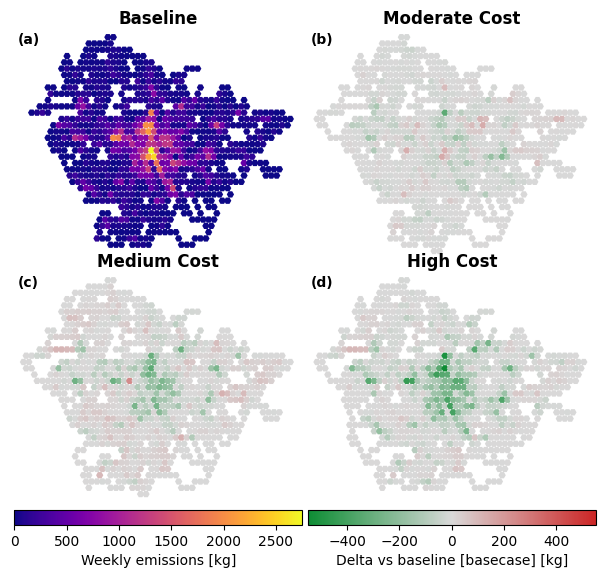

In [18]:
# 2x2 paper figure with improved contrast and reordered panels
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --- Order of panels ---
other_scens = ["batchmoderate", "batchmedium", "batchhigh"]  # desired order

# Title mapping for bold scenario names
title_map = {
    "baseline": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}

# Common extent and ranges
bounds = weekly_hex[BASE].total_bounds
x1, y1, x2, y2 = bounds
EPS = 1e-12

base_gdf = weekly_hex[BASE]
base_vmax = float(np.nanmax(base_gdf["emissions_kg_week"].to_numpy())) if len(base_gdf) else 1.0
base_vmin = 0.0

# Symmetric color range for deltas
acc = []
for scen in other_scens:
    comp = weekly_hex[scen + "_delta"]
    if len(comp):
        acc.append(np.nanmax(np.abs(comp["delta_kg"].to_numpy())))
delta_max_abs = float(np.nanmax(acc)) if acc else 1.0
delta_vmin, delta_vmax = -delta_max_abs, delta_max_abs

# --- Colormaps ---
# Base stays plasma for intensity
cmap_base = mpl.cm.plasma

# Custom red gray green for deltas with gray midpoint at zero
# Negative deltas -> green, zero -> gray, positive deltas -> red
colors_delta = [
    (0.05, 0.55, 0.20),   # green
    (0.85, 0.85, 0.85),   # gray for ~0
    (0.80, 0.15, 0.15)    # red
]
cmap_delta = mpl.colors.LinearSegmentedColormap.from_list("red_gray_green", colors_delta, N=256)

# --- Layout: 2x2 grid with two colorbars below ---
fig = plt.figure(figsize=(7.5, 6.5))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1, 1, 0.06], hspace=0.02, wspace=0.02)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
cb_ax_base  = fig.add_subplot(gs[2, 0])
cb_ax_delta = fig.add_subplot(gs[2, 1])

# --- Plot helper ---
def plot_masked(gdf, column, ax, vmin=None, vmax=None, cmap=None):
    gdf.plot(
        column=column,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        linewidth=0.0,
        edgecolor="none",
        legend=False
    )
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_axis_off()
    ax.set_aspect("equal", adjustable="box")

# --- Baseline ---
gdf_base_plot = base_gdf.loc[base_gdf["emissions_kg_week"] > EPS].copy()
plot_masked(gdf_base_plot, "emissions_kg_week", ax00, vmin=base_vmin, vmax=base_vmax, cmap=cmap_base)
ax00.set_title(title_map["baseline"], pad=2, fontweight="bold")
ax00.text(0.01, 0.98, "(a)", transform=ax00.transAxes, va="top", ha="left", fontsize=10, weight="bold")

# --- Deltas: moderate, medium, high ---
for ax, scen, label in zip([ax01, ax10, ax11], other_scens, ["(b)", "(c)", "(d)"]):
    comp = weekly_hex[scen + "_delta"]
    if len(comp) == 0:
        ax.set_axis_off()
        continue
    gdf_delta_plot = comp.loc[~np.isclose(comp["delta_kg"].to_numpy(), 0.0, atol=EPS)].copy()
    if len(gdf_delta_plot) == 0:
        ax.set_xlim(x1, x2)
        ax.set_ylim(y1, y2)
        ax.set_axis_off()
        ax.set_aspect("equal", adjustable="box")
    else:
        plot_masked(gdf_delta_plot, "delta_kg", ax, vmin=delta_vmin, vmax=delta_vmax, cmap=cmap_delta)
    ax.set_title(title_map[scen], pad=2, fontweight="bold")
    ax.text(0.01, 0.98, label, transform=ax.transAxes, va="top", ha="left", fontsize=10, weight="bold")

# --- Colorbars ---
sm_base = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=base_vmin, vmax=base_vmax), cmap=cmap_base)
cbar_base = fig.colorbar(sm_base, cax=cb_ax_base, orientation="horizontal")
cbar_base.set_label("Weekly emissions [kg]")

sm_delta = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=delta_vmin, vmax=delta_vmax), cmap=cmap_delta)
cbar_delta = fig.colorbar(sm_delta, cax=cb_ax_delta, orientation="horizontal")
cbar_delta.set_label(f"Delta vs baseline [{BASE}] [kg]")

plt.tight_layout()
plt.savefig("weekly_2x2_panels_paper.pdf", dpi=300, bbox_inches="tight")
plt.show()


Clip to Region


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3888495271.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outline = regionclusters.unary_union


Clip to Region


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3888495271.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outline = regionclusters.unary_union


Clip to Region


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3888495271.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outline = regionclusters.unary_union


Clip to Region


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3888495271.py:110: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outline = regionclusters.unary_union
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3888495271.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


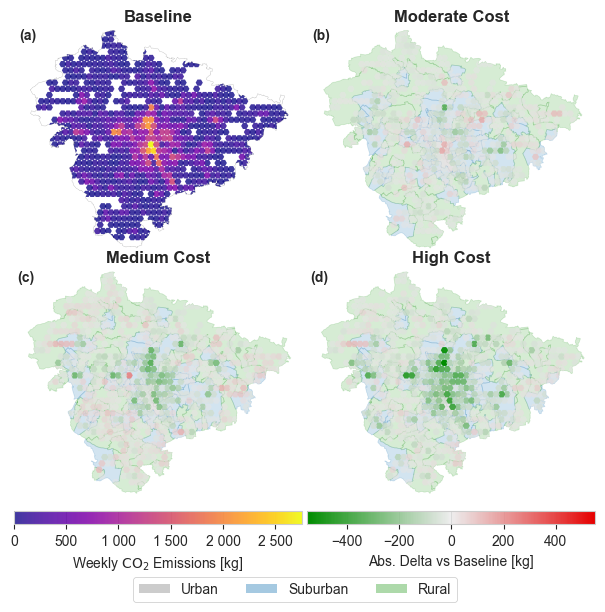

In [127]:
# 2x2 paper figure with zero filtering for deltas and separate alpha control for low values
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

# ===== User parameters =====
FIGSIZE = (7.5, 6.5)
DPI = 300
OUTFILE = "weekly_2x2_panels_paper.pdf"

# Drop very small delta values entirely
DELTA_ZERO_ABS = 1e-6       # absolute cut off in kg
DELTA_ZERO_REL = 0.005      # relative cut off as fraction of max absolute delta
DROP_NEAR_ZERO_DELTAS = True

# Alpha control
BASE_ALPHA_MIN  = 0.8      # alpha at the lowest baseline value
DELTA_ALPHA_MIN = 0.0  # fully transparent at zero
DELTA_ALPHA_MAX = 1.0  # fully opaque at strong deltas
# Alpha shapes
# baseline alpha grows with value from BASE_ALPHA_MIN to 1
# delta alpha is minimal at zero and grows toward both extremes up to 1

# --- Order of panels ---
other_scens = ["batchmoderate", "batchmedium", "batchhigh"]

# Title mapping for bold scenario names
title_map = {
    "baseline": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}

# Common extent and ranges
bounds = weekly_hex[BASE].total_bounds
x1, y1, x2, y2 = bounds
EPS = 1e-12

base_gdf = weekly_hex[BASE]
base_vmax = float(np.nanmax(base_gdf["emissions_kg_week"].to_numpy())) if len(base_gdf) else 1.0
base_vmin = 0.0

# Symmetric color range for deltas
acc = []
for scen in other_scens:
    comp = weekly_hex[scen + "_delta"]
    if len(comp):
        acc.append(np.nanmax(np.abs(comp["delta_kg"].to_numpy())))
delta_max_abs = float(np.nanmax(acc)) if acc else 1.0
delta_vmin, delta_vmax = -delta_max_abs, delta_max_abs

# Effective zero threshold for deltas
DELTA_ZERO_EFF = max(DELTA_ZERO_ABS, DELTA_ZERO_REL * delta_max_abs)

# --- Base colormaps without alpha shaping ---
cmap_base_raw = mpl.cm.plasma

# Diverging map for deltas: green -> gray -> red
colors_delta = [
    (0.00, 0.55, 0.00),   # saturated green
    (0.90, 0.90, 0.90),   # lighter gray near zero
    (0.90, 0.00, 0.00)    # saturated red
]
cmap_delta_raw = mpl.colors.LinearSegmentedColormap.from_list("red_gray_green", colors_delta, N=256)

def make_colormap_with_alpha(base_cmap, alpha_profile):
    """Sample a base cmap and replace alpha channel using alpha_profile defined on [0,1]."""
    N = 256
    t = np.linspace(0.0, 1.0, N)
    rgba = base_cmap(t)
    alphas = np.clip(alpha_profile(t), 0.0, 1.0)
    rgba[:, -1] = alphas
    return mpl.colors.ListedColormap(rgba)

# Alpha profiles
def alpha_profile_baseline(t):
    # t=0 at vmin, t=1 at vmax
    return BASE_ALPHA_MIN + (1.0 - BASE_ALPHA_MIN) * t

def alpha_profile_delta(t, gamma=0.1):
    """
    Nonlinear alpha profile emphasizing small deviations.
    t ∈ [0, 1], center (0.5) = zero delta.
    """
    # Map 0–1 to distance from 0.5
    dist = np.abs(t - 0.5) * 2.0  # now 0 at center, 1 at edges
    dist = np.clip(dist, 0.0, 1.0)
    # Nonlinear (gamma < 1 → steeper rise at small values)
    alpha = DELTA_ALPHA_MIN + (DELTA_ALPHA_MAX - DELTA_ALPHA_MIN) * (dist ** gamma)
    return alpha

# Define outline colors for area types
category_color_dict_agg = {
    "Urban": "#808080",
    "Suburban": "#1f78b4",
    "Rural": "#33a02c",
}

# Helper to clip a GeoDataFrame to the unified outline of regionclusters
def clip_to_region_outline(gdf, regionclusters):
    """
    Clips gdf to the unary_union outline of regionclusters.
    Requires matching CRS.
    """
    if gdf.crs != regionclusters.crs:
        regionclusters = regionclusters.to_crs(gdf.crs)
    outline = regionclusters.unary_union
    # Fast bounding box prefilter, then precise clip
    gdf = gdf[gdf.geometry.intersects(gpd.GeoSeries([outline], crs=gdf.crs).iloc[0].envelope)]
    return gpd.clip(gdf, outline)

def draw_area_type_outlines(ax):
    """
    Draw regionclusters as outlines only, colored by area_type_agg.
    No fill, per category edgecolor, thin lines, above the hex layer.
    """
    # Keep current view limits so the overlay does not change the extent
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Plot each category as outlines only
    for cat, color in category_color_dict_agg.items():
        sub = regionclusters.loc[regionclusters["area_type_agg"] == cat]
        if len(sub) == 0:
            continue
        sub.boundary.plot(
            ax=ax,
            facecolor=color,
            edgecolor=color,
            linewidth=0.5,
            alpha = 0.2,
            zorder=0,
        )

    # Restore limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Build colormaps with embedded alpha
cmap_base_alpha  = make_colormap_with_alpha(cmap_base_raw,  alpha_profile_baseline)
cmap_delta_alpha = make_colormap_with_alpha(cmap_delta_raw, alpha_profile_delta)

# --- Plot helper using colormap embedded alpha ---
def plot_masked(gdf, column, ax, vmin=None, vmax=None, cmap=None, clip_region=None, zero_eps=0.0):
    """
    Plots gdf[column] with optional clip to clip_region and filters out near zero values.
    zero_eps defines the absolute epsilon for zero filtering.
    """
    
    # Optional clip to region outline
    if clip_region is not None and len(clip_region) > 0:
        try:
            print("Clip to Region")
            gdf_nz = clip_to_region_outline(gdf, clip_region)
        except Exception as e:
            # Fallback without clip if topology is invalid
            pass
        
    gdf_nz.plot(
        column=column,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        linewidth=0.0,
        edgecolor="none",
        legend=False,
    )    

        
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_axis_off()
    ax.set_aspect("equal", adjustable="box")

# --- Layout: 2x2 grid with two colorbars below ---
fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1, 1.1, 0.06], hspace=0.02, wspace=0.02)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
cb_ax_base  = fig.add_subplot(gs[2, 0])
cb_ax_delta = fig.add_subplot(gs[2, 1])

# --- Baseline ---
gdf_base_plot = base_gdf.loc[base_gdf["emissions_kg_week"] > EPS].copy()
plot_masked(
    gdf_base_plot, "emissions_kg_week", ax00,
    vmin=base_vmin, vmax=base_vmax, cmap=cmap_base_alpha, clip_region=regionclusters
)
ax00.set_title(title_map["baseline"], pad=2, fontweight="bold")
ax00.text(0.01, 0.98, "(a)", transform=ax00.transAxes, va="top", ha="left", fontsize=10, weight="bold")

# Draw only the outer outline of all regionclusters (single smooth border)
outline = regionclusters.union_all()  # shapely >= 2.0, replaces unary_union

gpd.GeoSeries([outline], crs=regionclusters.crs).boundary.plot(
    ax=ax00,
    color="black",        # outline color (set to "black" or any preferred color)
    linewidth=0.25,        # slightly thicker for visibility
    alpha=0.3,            # mostly opaque
    zorder=50,
)


# --- Deltas: moderate, medium, high ---
for ax, scen, label in zip([ax01, ax10, ax11], other_scens, ["(b)", "(c)", "(d)"]):
    comp = weekly_hex[scen + "_delta"]
    if len(comp) == 0:
        ax.set_axis_off()
        continue

    if DROP_NEAR_ZERO_DELTAS:
        vals = comp["delta_kg"].to_numpy()
        keep_mask = np.abs(vals) >= DELTA_ZERO_EFF
        gdf_delta_plot = comp.loc[keep_mask].copy()
    else:
        gdf_delta_plot = comp.copy()

    if len(gdf_delta_plot) == 0:
        ax.set_xlim(x1, x2)
        ax.set_ylim(y1, y2)
        ax.set_axis_off()
        ax.set_aspect("equal", adjustable="box")
    else:
        plot_masked(
            gdf_delta_plot, "delta_kg", ax,
            vmin=delta_vmin, vmax=delta_vmax, cmap=cmap_delta_alpha, clip_region=regionclusters
        )
    ax.set_title(title_map[scen], pad=2, fontweight="bold")
    ax.text(0.01, 0.98, label, transform=ax.transAxes, va="top", ha="left", fontsize=10, weight="bold")
    draw_area_type_outlines(ax)

# --- Colorbars using same alpha shaped colormaps ---
sm_base  = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=base_vmin,  vmax=base_vmax),  cmap=cmap_base_alpha)
sm_delta = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=delta_vmin, vmax=delta_vmax), cmap=cmap_delta_alpha)

cbar_base = fig.colorbar(sm_base,  cax=cb_ax_base,  orientation="horizontal")
cbar_base.set_label("Weekly $\\mathrm{CO_2}$ Emissions [kg]", fontsize=10, labelpad=4)
# Formatter mit Tausendertrennzeichen (Leerzeichen statt Komma)
formatter = FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " "))
cbar_base.ax.xaxis.set_major_formatter(formatter)

cbar_delta = fig.colorbar(sm_delta, cax=cb_ax_delta, orientation="horizontal")
cbar_delta.set_label("Abs. Delta vs Baseline [kg]")

from matplotlib.lines import Line2D

# Build legend handles from your outline colors
area_handles = [
    Patch(facecolor=category_color_dict_agg["Urban"],     edgecolor="none", alpha=0.4, label="Urban"),
    Patch(facecolor=category_color_dict_agg["Suburban"],  edgecolor="none", alpha=0.4, label="Suburban"),
    Patch(facecolor=category_color_dict_agg["Rural"],     edgecolor="none", alpha=0.4, label="Rural"),
]


# Place a centered legend below both colorbars
leg = fig.legend(
    handles=area_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),  # tweak vertical offset if needed
    handlelength=2.2,
    columnspacing=2.0,
)

# Optionally style the legend frame
leg.get_frame().set_linewidth(0.6)
leg.get_frame().set_alpha(0.9)

# Make room at the bottom so the legend does not overlap
# plt.subplots_adjust(bottom=0.14)

plt.tight_layout()
plt.savefig(OUTFILE, dpi=DPI, bbox_inches="tight")
plt.show()


In [68]:
regionclusters

,geometry,name,raumtyp,area_type_agg,area_type
no,,,,,
1,"POLYGON ((550245.757 5803780.217, 550498.506 5...",Metropoles Zentrum,1,Urban,Metropolitan Center
2,"MULTIPOLYGON (((551841.918 5799807.714, 551822...",Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use
3,"MULTIPOLYGON (((550296.319 5800661.942, 550326...",Zentrumsnah verdichtete Mischnutzung,3,Urban,Dense Mixed Use
4,"MULTIPOLYGON (((542990.22 5792838.808, 542717....",Städtisch mit Verdichtungsansätzen,4,Suburban,Residential Use
5,"MULTIPOLYGON (((533343.972 5795245.288, 533438...",Städtisch mit gewerblicher Prägung,5,Suburban,Industrial Use
6,"MULTIPOLYGON (((539564.746 5778344.203, 539245...",Umland Verstädtert,6,Suburban,Urbanized Periphery
7,"MULTIPOLYGON (((534107.141 5781642.14, 534005....",Umland dörflich mit geringem gewerblichem Einf...,7,Rural,Rural with Industrial Influence
8,"MULTIPOLYGON (((535733.341 5790668.537, 535432...",Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence


In [103]:
# Weekly aggregation for scenarios: basecase, batchhigh, batchmedium, batchmoderate
import numpy as np

# Preconditions: df_all (concatenated DataFrame with run_name) and OUTPUT_BASE defined in cell 1
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the first cell to load emissions results.")

# Helper: extract emissions total safely
def _emissions_total(x):
    if isinstance(x, dict):
        return float(x.get('total', 0.0) or 0.0)
    return 0.0

work = df_all.copy()
if 'run_name' not in work.columns:
    raise KeyError("run_name column missing in df_all; ensure loading step added it.")

# tour_km coercion
if 'tour_km' not in work.columns:
    if 'tour_distance_km' in work.columns:
        work['tour_km'] = pd.to_numeric(work['tour_distance_km'], errors='coerce')
    else:
        work['tour_km'] = np.nan
else:
    work['tour_km'] = pd.to_numeric(work['tour_km'], errors='coerce')

# duration in hours: use multiple fallbacks
_duration = None
if 'Tour Duration (hrs)' in work.columns:
    _duration = pd.to_numeric(work['Tour Duration (hrs)'], errors='coerce')
elif 'Duration' in work.columns:
    dur = pd.to_numeric(work['Duration'], errors='coerce')
    max_dur = dur.max(skipna=True)
    _duration = dur / 3600.0 if pd.notna(max_dur) and max_dur > 600 else dur
else:
    _duration = pd.Series(np.nan, index=work.index)

# Fallback: parse 'Tour Duration formatted' like '1970-01-01 13:18:47' -> 13.3131 hours
if 'Tour Duration formatted' in work.columns:
    dt = pd.to_datetime(work['Tour Duration formatted'], errors='coerce')
    # If timezone encoded as pandas datetime64, it won't affect hour/min/sec extraction
    duration_from_formatted = (
        dt.dt.hour.astype('float64')
        + dt.dt.minute.astype('float64') / 60.0
        + dt.dt.second.astype('float64') / 3600.0
        + (getattr(dt.dt, 'microsecond', pd.Series(0, index=dt.index)).astype('float64') / 3_600_000_000.0)
    )
    # Only fill where _duration is NaN or missing
    _duration = _duration.where(~_duration.isna(), duration_from_formatted)

work['duration_hours'] = _duration

# emissions total per row
work['emissions_total'] = work['emissions'].map(_emissions_total) if 'emissions' in work.columns else 0.0

# Load factor detection and coercion
load_factor_candidates = [
    'vehicle_load_factor', 'Vehicle Load Factor', 'load_factor', 'Load Factor', 'veh_load_factor'
]
lf_col = next((c for c in load_factor_candidates if c in work.columns), None)
if lf_col is not None:
    work['vehicle_load_factor_num'] = pd.to_numeric(work[lf_col], errors='coerce')
else:
    work['vehicle_load_factor_num'] = np.nan

# Week and scenarios
week_days = ['12052025', '13052025', '14052025', '15052025', '16052025', '17052025']
scenarios = ['basecase', 'batchhigh', 'batchmedium', 'batchmoderate']
suffix = 'iter150_jsprit100'

present_runs = set(work['run_name'].astype(str).unique())
scenario_runs = {}
for scen in scenarios:
    intended = [f"{scen}_{d}_{suffix}" for d in week_days]
    available = [r for r in intended if r in present_runs]
    scenario_runs[scen] = available

records = []
for scen, runs in scenario_runs.items():
    sub = work[work['run_name'].isin(runs)].copy()
    if sub.empty:
        records.append({
            'scenario': scen,
            'runs_found': 0,
            'vehicles_rows': 0,
            'unique_vehicles': 0,
            'total_tour_km': 0.0,
            'avg_tour_km_per_vehicle': np.nan,
            'avg_duration_hours': np.nan,
            'total_emissions': 0.0,
            'avg_total_tour_km_per_run': np.nan,
            'avg_vehicle_load_factor': np.nan,
            'missing_runs': len([r for r in [f"{scen}_{d}_{suffix}" for d in week_days] if r not in present_runs])
        })
        continue

    vehicles_rows = len(sub)
    unique_vehicles = sub['vehicle_id'].nunique() if 'vehicle_id' in sub.columns else np.nan
    total_tour_km = sub['tour_km'].sum(min_count=1)
    avg_tour_km_per_vehicle = sub['tour_km'].mean()
    avg_duration_hours = sub['duration_hours'].mean()
    total_emissions = sub['emissions_total'].sum(min_count=1)
    avg_vehicle_load_factor = sub['vehicle_load_factor_num'].mean()

    per_run_totals = sub.groupby('run_name', as_index=False)['tour_km'].sum()
    avg_total_tour_km_per_run = per_run_totals['tour_km'].mean() if not per_run_totals.empty else np.nan

    records.append({
        'scenario': scen,
        'runs_found': len(runs),
        'vehicles_rows': int(vehicles_rows),
        'unique_vehicles': int(unique_vehicles) if not pd.isna(unique_vehicles) else 0,
        'total_tour_km': float(total_tour_km) if pd.notna(total_tour_km) else 0.0,
        'avg_tour_km_per_vehicle': float(avg_tour_km_per_vehicle) if pd.notna(avg_tour_km_per_vehicle) else np.nan,
        'avg_duration_hours': float(avg_duration_hours) if pd.notna(avg_duration_hours) else np.nan,
        'total_emissions': float(total_emissions) if pd.notna(total_emissions) else 0.0,
        'avg_total_tour_km_per_run': float(avg_total_tour_km_per_run) if pd.notna(avg_total_tour_km_per_run) else np.nan,
        'avg_vehicle_load_factor': float(avg_vehicle_load_factor) if pd.notna(avg_vehicle_load_factor) else np.nan,
        'missing_runs': len([r for r in [f"{scen}_{d}_{suffix}" for d in week_days] if r not in runs])
    })

weekly_summary = pd.DataFrame.from_records(records)

out_parquet = os.path.join(OUTPUT_BASE, 'weekly_summary_emissions.parquet')
out_csv = os.path.join(OUTPUT_BASE, 'weekly_summary_emissions.csv')

try:
    weekly_summary.to_parquet(out_parquet, index=False)
    print(f"[OK] Saved weekly summary to {out_parquet}")
except Exception as e:
    print(f"[WARN] Failed to save parquet: {e}")

try:
    weekly_summary.to_csv(out_csv, index=False)
    print(f"[OK] Saved weekly summary to {out_csv}")
except Exception as e:
    print(f"[WARN] Failed to save csv: {e}")

weekly_summary

[OK] Saved weekly summary to C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_summary_emissions.parquet
[OK] Saved weekly summary to C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\weekly_summary_emissions.csv


,scenario,runs_found,vehicles_rows,unique_vehicles,total_tour_km,avg_tour_km_per_vehicle,avg_duration_hours,total_emissions,avg_total_tour_km_per_run,avg_vehicle_load_factor,missing_runs
0,basecase,6,9979,5916,927238.192153,92.918949,7.647579,1.798067e+08,154539.698692,0.675269,0
1,batchhigh,6,9661,7607,838779.965191,86.821236,7.381228,1.527186e+08,139796.660865,0.703039,0
2,batchmedium,6,10031,7698,942631.897607,93.971877,7.451047,1.717080e+08,157105.316268,0.683717,0
3,batchmoderate,6,9804,6492,902140.653500,92.017611,7.643659,1.742320e+08,150356.775583,0.682107,0


In [9]:
# emissions_total
def _emissions_total(x):
    if isinstance(x, dict):
        return float(x.get('total', 0.0) or 0.0)
    return 0.0
df_all['emissions_total'] = df_all['emissions'].map(_emissions_total) if 'emissions' in df_all.columns else 0.0

In [184]:
# Per-day (run-level) aggregation per scenario; also show Mon–Wed subset
import numpy as np

# Preconditions
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the first cell first.")

work = df_all.copy()
if 'run_name' not in work.columns:
    raise KeyError("run_name column missing in df_all; ensure loading step added it.")

# Reuse numeric coercions and derived columns if not present
if 'tour_km' not in work.columns and 'tour_distance_km' in work.columns:
    work['tour_km'] = pd.to_numeric(work['tour_distance_km'], errors='coerce')
else:
    work['tour_km'] = pd.to_numeric(work.get('tour_km', np.nan), errors='coerce')

# duration_hours from weekly cell if exists, otherwise reconstruct
if 'duration_hours' not in work.columns:
    _duration = None
    if 'Tour Duration (hrs)' in work.columns:
        _duration = pd.to_numeric(work['Tour Duration (hrs)'], errors='coerce')
    elif 'Duration' in work.columns:
        dur = pd.to_numeric(work['Duration'], errors='coerce')
        max_dur = dur.max(skipna=True)
        _duration = dur / 3600.0 if pd.notna(max_dur) and max_dur > 600 else dur
    else:
        _duration = pd.Series(np.nan, index=work.index)
    if 'Tour Duration formatted' in work.columns:
        dt = pd.to_datetime(work['Tour Duration formatted'], errors='coerce')
        duration_from_formatted = (
            dt.dt.hour.astype('float64')
            + dt.dt.minute.astype('float64') / 60.0
            + dt.dt.second.astype('float64') / 3600.0
            + (getattr(dt.dt, 'microsecond', pd.Series(0, index=dt.index)).astype('float64') / 3_600_000_000.0)
        )
        _duration = _duration.where(~_duration.isna(), duration_from_formatted)
    work['duration_hours'] = _duration

# emissions_total
def _emissions_total(x):
    if isinstance(x, dict):
        return float(x.get('total', 0.0) or 0.0)
    return 0.0
work['emissions_total'] = work['emissions'].map(_emissions_total) if 'emissions' in work.columns else 0.0

# load factor numeric
lf_col = None
for c in ['vehicle_load_factor', 'Vehicle Load Factor', 'load_factor', 'Load Factor', 'veh_load_factor']:
    if c in work.columns:
        lf_col = c
        break
if lf_col:
    work['vehicle_load_factor_num'] = pd.to_numeric(work[lf_col], errors='coerce')
else:
    work['vehicle_load_factor_num'] = np.nan

# Parse day token from run_name to map weekday; expected pattern <scenario>_<DDMMYYYY>_iter150_jsprit100
def _extract_day(run):
    parts = str(run).split('_')
    if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8:
        return parts[1]
    return None
work['day_token'] = work['run_name'].map(_extract_day)

# Map day_token to weekday label (Mon..Sun)
import datetime as _dt

def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)

# Compute per-run (day) totals, then aggregate per scenario x day
group_cols = ['scenario', 'day_token', 'weekday', 'run_name']
# Derive scenario from run_name prefix
work['scenario'] = work['run_name'].str.split('_').str[0]

per_run = work.groupby(group_cols, dropna=False).agg(
    vehicles_rows=('run_name','size'),
    unique_vehicles=('vehicle_id', lambda s: s.nunique() if 'vehicle_id' in work.columns else np.nan),
    total_tour_km=('tour_km','sum'),
    avg_tour_km_per_vehicle=('tour_km','mean'),
    avg_duration_hours=('duration_hours','mean'),
    total_emissions=('emissions_total','sum'),
    avg_vehicle_load_factor=('vehicle_load_factor_num','mean')
).reset_index()

# Persist and show Mon–Wed subset by scenario
daily_out_parquet = os.path.join(OUTPUT_BASE, 'daily_summary_emissions.parquet')
daily_out_csv = os.path.join(OUTPUT_BASE, 'daily_summary_emissions.csv')

try:
    per_run.to_parquet(daily_out_parquet, index=False)
    print(f"[OK] Saved daily summary to {daily_out_parquet}")
except Exception as e:
    print(f"[WARN] Failed to save parquet: {e}")

try:
    per_run.to_csv(daily_out_csv, index=False)
    print(f"[OK] Saved daily summary to {daily_out_csv}")
except Exception as e:
    print(f"[WARN] Failed to save csv: {e}")

# Filter Mon–Wed view for convenience
mon_wed = per_run[per_run['weekday'].isin(['Mon','Tue','Wed'])].copy()
# Show by scenario with a compact sort
mon_wed.sort_values(['scenario','weekday','run_name']).reset_index(drop=True)

[OK] Saved daily summary to C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\daily_summary_emissions.parquet
[OK] Saved daily summary to C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\daily_summary_emissions.csv


,scenario,day_token,weekday,run_name,vehicles_rows,unique_vehicles,total_tour_km,avg_tour_km_per_vehicle,avg_duration_hours,total_emissions,avg_vehicle_load_factor
0,basecase,12052025,Mon,basecase_12052025_iter150_jsprit100,1636,1636,148222.279924,90.600416,7.632768,2.856664e+07,0.682647
1,basecase,13052025,Tue,basecase_13052025_iter150_jsprit100,1724,1724,154676.646027,89.719632,7.636138,3.013394e+07,0.688804
2,basecase,14052025,Wed,basecase_14052025_iter150_jsprit100,1900,1900,166062.025358,87.401066,7.594068,3.260831e+07,0.687950
3,batchhigh,12052025,Mon,batchhigh_12052025_iter150_jsprit100,1912,1912,130183.102334,68.087397,7.206931,2.580671e+07,0.730254
4,batchhigh,13052025,Tue,batchhigh_13052025_iter150_jsprit100,1491,1491,163011.269305,109.330160,7.590710,2.833480e+07,0.666108
5,batchhigh,14052025,Wed,batchhigh_14052025_iter150_jsprit100,1364,1364,94233.786395,69.086354,7.143710,1.807254e+07,0.737175
6,batchmedium,12052025,Mon,batchmedium_12052025_iter150_jsprit100,2061,2061,182676.711517,88.634989,7.458818,3.390107e+07,0.702334
7,batchmedium,13052025,Tue,batchmedium_13052025_iter150_jsprit100,1518,1518,164822.312980,108.578599,7.545872,2.907319e+07,0.651186
8,batchmedium,14052025,Wed,batchmedium_14052025_iter150_jsprit100,1455,1455,113325.347000,77.886836,7.230311,2.187982e+07,0.698493
9,batchmoderate,12052025,Mon,batchmoderate_12052025_iter150_jsprit100,1849,1849,157204.344680,85.021279,7.626634,3.071538e+07,0.702621


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39968\1570678313.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['scenario', 'weekday'], as_index=False)['total_emissions_t']


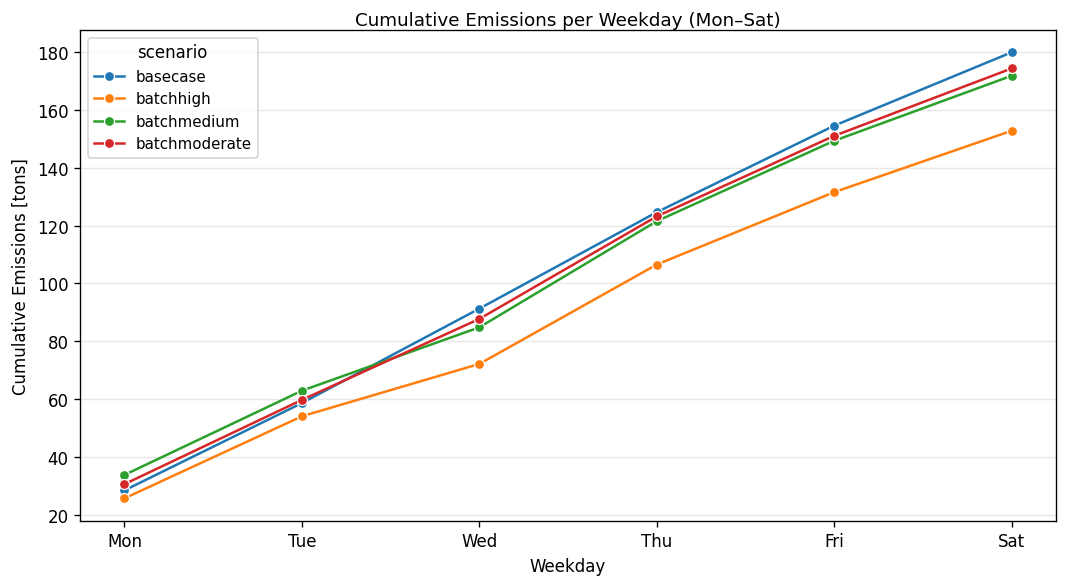

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\plot_cumulative_emissions_tons_combined.png


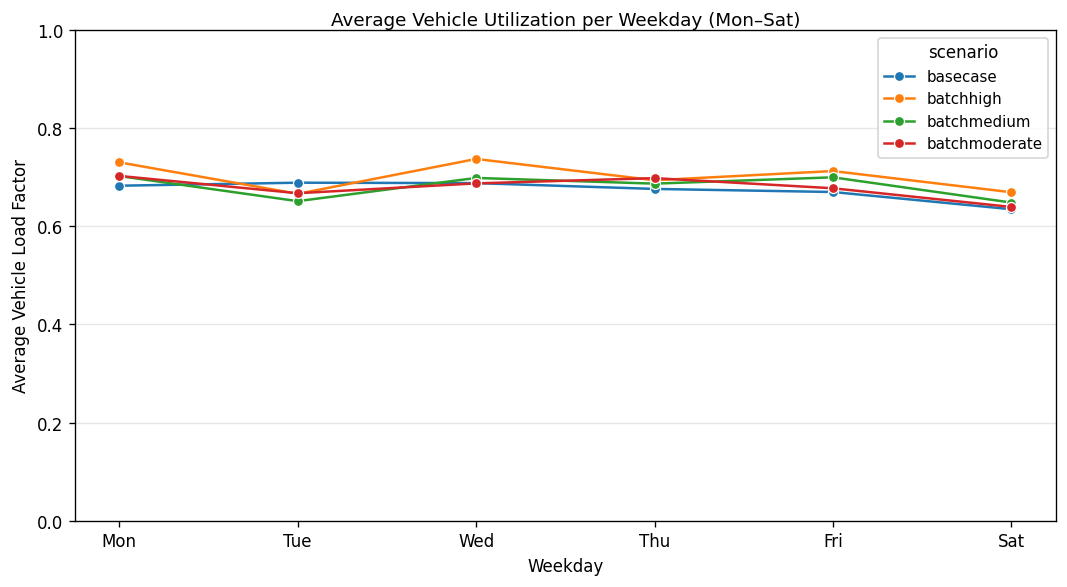

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\emissions_fix\plot_avg_utilization_lines_combined.png


In [185]:
# Combined line plots: cumulative emissions (in tons) and average utilization per weekday (Mon–Sat)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load daily summary (parquet preferred)
_daily_path_parquet = os.path.join(OUTPUT_BASE, 'daily_summary_emissions.parquet')
_daily_path_csv = os.path.join(OUTPUT_BASE, 'daily_summary_emissions.csv')
try:
    daily = pd.read_parquet(_daily_path_parquet)
except Exception:
    daily = pd.read_csv(_daily_path_csv)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

# Filter and enforce weekday order
if 'weekday' not in daily.columns:
    raise RuntimeError("daily_summary_emissions missing 'weekday' column. Run the daily aggregation cell first.")

daily = daily[daily['weekday'].isin(weekday_order)].copy()
daily['weekday'] = pd.Categorical(daily['weekday'], categories=weekday_order, ordered=True)

# Convert total emissions to tons (1 ton = 1e6 grams)
if 'total_emissions' in daily.columns:
    daily['total_emissions_t'] = pd.to_numeric(daily['total_emissions'], errors='coerce') / 1e6
else:
    raise RuntimeError("'total_emissions' column missing in daily summary.")

# --- 1) Combined line plot: cumulative emissions (in tons) per weekday ---
em = (
    daily[['scenario', 'weekday', 'total_emissions_t']]
    .groupby(['scenario', 'weekday'], as_index=False)['total_emissions_t']
    .sum()
)
em = em.sort_values(['scenario', 'weekday'])
em['cum_t'] = em.groupby('scenario', group_keys=False)['total_emissions_t'].cumsum()

plt.figure(figsize=(9, 5))
sns.lineplot(data=em, x='weekday', y='cum_t', hue='scenario', marker='o')
plt.title('Cumulative Emissions per Weekday (Mon–Sat)')
plt.ylabel('Cumulative Emissions [tons]')
plt.xlabel('Weekday')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig_em_combined = os.path.join(OUTPUT_BASE, 'plot_cumulative_emissions_tons_combined.png')
plt.savefig(fig_em_combined, dpi=150)
plt.show()
print(f"[OK] Saved {fig_em_combined}")

# --- 2) Combined line plot: average vehicle utilization per weekday ---
if 'avg_vehicle_load_factor' in daily.columns and not daily['avg_vehicle_load_factor'].isna().all():
    util_daily = daily[['scenario', 'weekday', 'avg_vehicle_load_factor']].copy()
else:
    # Fallback: compute from df_all if available
    if 'df_all' not in globals() or df_all is None:
        raise RuntimeError('df_all not available to compute utilization; run loader cell first or ensure daily summary has avg_vehicle_load_factor.')

    raw = df_all.copy()
    raw['scenario'] = raw['run_name'].str.split('_').str[0]

    def _extract_day(run):
        parts = str(run).split('_')
        return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None
    raw['day_token'] = raw['run_name'].map(_extract_day)

    import datetime as _dt
    def _weekday_label(day_token):
        try:
            d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
            return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
        except Exception:
            return None
    raw['weekday'] = raw['day_token'].map(_weekday_label)

    lf_candidates = ['vehicle_load_factor', 'Vehicle Load Factor', 'load_factor', 'Load Factor', 'veh_load_factor']
    lf_col = next((c for c in lf_candidates if c in raw.columns), None)
    if lf_col is None:
        raise RuntimeError('No vehicle load factor column found in df_all to compute utilization.')

    raw['vehicle_load_factor_num'] = pd.to_numeric(raw[lf_col], errors='coerce')
    raw = raw[raw['weekday'].isin(weekday_order)].copy()

    util_daily = (
        raw.groupby(['scenario', 'weekday'])['vehicle_load_factor_num']
        .mean().reset_index(name='avg_vehicle_load_factor')
    )

util_daily['weekday'] = pd.Categorical(util_daily['weekday'], categories=weekday_order, ordered=True)
util_daily = util_daily.sort_values(['scenario', 'weekday'])

plt.figure(figsize=(9, 5))
sns.lineplot(data=util_daily, x='weekday', y='avg_vehicle_load_factor', hue='scenario', marker='o')
plt.title('Average Vehicle Utilization per Weekday (Mon–Sat)')
plt.ylabel('Average Vehicle Load Factor')
plt.xlabel('Weekday')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig_util_combined = os.path.join(OUTPUT_BASE, 'plot_avg_utilization_lines_combined.png')
plt.savefig(fig_util_combined, dpi=150)
plt.show()
print(f"[OK] Saved {fig_util_combined}")


In [36]:
import pandas as pd
import numpy as np

# ---------------- Helpers ----------------
def pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise RuntimeError(f"Required column not found. Tried: {candidates}")
    return None

def determine_area_type(raumtyp):
    try:
        v = int(raumtyp)
    except Exception:
        return "unknown"
    if v in (1, 2, 3): return "Urban"
    if v in (4, 5, 6): return "Suburban"
    if v in (7, 8):    return "Rural"
    return "unknown"

def normalize_scenario_label(s: str) -> str:
    s = str(s).lower()
    if s.startswith("base"):          # base, basecase, baseline, etc.
        return "baseline"
    if s.startswith("batchmoderate"):
        return "batchmoderate"
    if s.startswith("batchmedium"):
        return "batchmedium"
    if s.startswith("batchhigh"):
        return "batchhigh"
    return s

# ---------------- Prechecks ----------------
# Accept link_id as index OR column
if "raumtyp" not in networkplus.columns:
    raise RuntimeError("networkplus must contain column 'raumtyp'.")

if networkplus.index.name == "link_id":
    networkplus = networkplus.reset_index()
elif "link_id" not in networkplus.columns:
    raise RuntimeError("networkplus must contain or index 'link_id'.")

run_col_all = pick_col(df_all, ["run_name"])
veh_col     = pick_col(df_all, ["vehicle_id", "veh_id"])
em_col_all  = pick_col(df_all, ["emissions_total", "emissions_g"])
km_col_all  = pick_col(df_all, ["tour_km", "Tour_km"])
deliv_col   = pick_col(df_all, ["deliveries", "parcels"], required=False)

run_col_15  = pick_col(df_all_15min, ["run_name"])
link_col_15 = pick_col(df_all_15min, ["link_id"])
em_col_15   = pick_col(df_all_15min, ["emissions_total", "emissions_g"])

# ---------------- Config ----------------
SCEN_LABEL = {
    "baseline": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}
SCEN_ORDER = ["baseline", "batchmoderate", "batchmedium", "batchhigh"]

# ---------------- Scenario keys (normalized, no full copies) ----------------
scenario_s_all = (
    df_all[run_col_all].astype(str).str.split("_", n=1).str[0].map(normalize_scenario_label)
)
scenario_s_15 = (
    df_all_15min[run_col_15].astype(str).str.split("_", n=1).str[0].map(normalize_scenario_label)
)

# ---------------- Vehicle-based totals per scenario ----------------
df_all[em_col_all] = pd.to_numeric(df_all[em_col_all], errors="coerce").fillna(0).astype("float32")
df_all[km_col_all] = pd.to_numeric(df_all[km_col_all], errors="coerce").fillna(0).astype("float32")
if deliv_col is not None:
    df_all[deliv_col] = pd.to_numeric(df_all[deliv_col], errors="coerce").fillna(0).astype("float32")
else:
    deliv_col = "__deliveries_fallback__"
    if deliv_col not in df_all.columns:
        df_all[deliv_col] = np.float32(0)

agg = (
    df_all.groupby(scenario_s_all, observed=True, sort=False)
          .agg(
              total_em_g=(em_col_all, "sum"),
              total_deliveries=(deliv_col, "sum"),
              total_vehicle_km=(km_col_all, "sum"),
              n_vehicles=(veh_col, "nunique")
          )
          .rename_axis("scenario")
          .reset_index()
)

# Intensities and units
agg["total_em_t"]          = agg["total_em_g"].astype("float64") / 1e6
agg["em_per_parcel_g"]     = agg["total_em_g"] / np.maximum(agg["total_deliveries"], 1.0)
agg["em_per_vehiclekm_g"]  = agg["total_em_g"] / np.maximum(agg["total_vehicle_km"], 1.0)

# ---------------- Link-based area split (memory friendly) ----------------
work15 = df_all_15min[[run_col_15, link_col_15, em_col_15]]
work15 = work15.assign(
    **{em_col_15: pd.to_numeric(work15[em_col_15], errors="coerce").fillna(0).astype("float32")}
)

wk = (
    work15.groupby([scenario_s_15, link_col_15], observed=True, sort=False)[em_col_15]
          .sum()
          .rename("emissions_g_week")
          .reset_index()
)
wk = wk.rename(columns={wk.columns[0]: "scenario", link_col_15: "link_id"})

# Map area types via dict (faster than large merges)
rt_map = networkplus.set_index("link_id")["raumtyp"].to_dict()
wk["raumtyp"]   = wk["link_id"].map(rt_map)
wk["area_type"] = wk["raumtyp"].map(determine_area_type)
wk = wk[wk["area_type"].isin(["Urban", "Suburban", "Rural"])]

area_split_wide = (
    wk.groupby(["scenario", "area_type"], observed=True, sort=False)["emissions_g_week"]
      .sum()
      .unstack("area_type")
      .reindex(columns=["Urban", "Suburban", "Rural"])
      .fillna(0.0)
)
area_split_wide = area_split_wide.astype("float64") / 1e6  # to tons

# ---------------- Merge and deltas vs baseline ----------------
table = (
    agg.set_index("scenario")
       .join(area_split_wide, how="left")
       .fillna(0.0)
       .reindex(SCEN_ORDER)
)

if "baseline" not in table.index or table.loc["baseline"].isna().all():
    raise RuntimeError("Baseline scenario not found after normalization. Check run_name prefixes.")

baseline = table.loc["baseline"]

def pct_change(colname):
    base = float(baseline[colname]) if colname in baseline.index else 0.0
    denom = base if base != 0.0 and np.isfinite(base) else 1e-12
    return (table[colname] - base) / denom * 100.0

for c in ["total_em_t", "em_per_parcel_g", "em_per_vehiclekm_g", "Urban", "Suburban", "Rural"]:
    if c in table.columns:
        table[f"{c}_pct"] = pct_change(c)

# ---------------- Formatting (small summary only) ----------------
def fmt_val(base, pct):
    if pd.isna(pct) or abs(pct) < 0.05:
        return f"{base:,.2f}"
    sign = "+" if pct > 0 else "-"
    return f"{base:,.2f} ({sign}{abs(pct):.1f}%)"

table_round = table.round(2)

summary = pd.DataFrame({
    "Total Emissions [t]": [
        fmt_val(table_round.loc[s, "total_em_t"], table_round.loc[s, "total_em_t_pct"]) for s in SCEN_ORDER
    ],
    "Emissions per Parcel [g]": [
        fmt_val(table_round.loc[s, "em_per_parcel_g"], table_round.loc[s, "em_per_parcel_g_pct"]) for s in SCEN_ORDER
    ],
    "Emissions per Vehicle-km [g/km]": [
        fmt_val(table_round.loc[s, "em_per_vehiclekm_g"], table_round.loc[s, "em_per_vehiclekm_g_pct"]) for s in SCEN_ORDER
    ],
    "Urban [t]": [
        fmt_val(table_round.loc[s, "Urban"], table_round.loc[s, "Urban_pct"]) for s in SCEN_ORDER
    ],
    "Suburban [t]": [
        fmt_val(table_round.loc[s, "Suburban"], table_round.loc[s, "Suburban_pct"]) for s in SCEN_ORDER
    ],
    "Rural [t]": [
        fmt_val(table_round.loc[s, "Rural"], table_round.loc[s, "Rural_pct"]) for s in SCEN_ORDER
    ],
}, index=[SCEN_LABEL.get(s, s) for s in SCEN_ORDER])

print("\n=== Emissions Summary ===")
print(summary.to_string())

# Optional LaTeX export
latex_tbl = summary.to_latex(
    escape=False,
    column_format="lrrrrrr",
    caption="Weekly emissions across cost scenarios",
    label="tab:weekly_emissions"
)
print("\n\nLaTeX Table Preview:\n", latex_tbl)



=== Emissions Summary ===
              Total Emissions [t] Emissions per Parcel [g] Emissions per Vehicle-km [g/km]       Urban [t]    Suburban [t]      Rural [t]
Baseline                   179.81                   141.67                          193.92           25.05          108.59          46.01
Moderate Cost      174.23 (-3.1%)           137.33 (-3.1%)                  193.13 (-0.4%)   24.93 (-0.5%)  104.21 (-4.0%)  45.00 (-2.2%)
Medium Cost        171.71 (-4.5%)           135.53 (-4.3%)                  182.16 (-6.1%)   22.69 (-9.4%)  100.32 (-7.6%)  48.48 (+5.4%)
High Cost         152.72 (-15.1%)          120.53 (-14.9%)                  182.07 (-6.1%)  20.87 (-16.7%)  89.46 (-17.6%)  42.18 (-8.3%)


LaTeX Table Preview:
 \begin{table}
\caption{Weekly emissions across cost scenarios}
\label{tab:weekly_emissions}
\begin{tabular}{lrrrrrr}
\toprule
 & Total Emissions [t] & Emissions per Parcel [g] & Emissions per Vehicle-km [g/km] & Urban [t] & Suburban [t] & Rural [t] \\
\midrul

In [35]:
table

,total_em_g,total_deliveries,total_vehicle_km,n_vehicles,total_em_t,em_per_parcel_g,em_per_vehiclekm_g,Urban,Suburban,Rural,total_em_t_pct,em_per_parcel_g_pct,em_per_vehiclekm_g_pct,Urban_pct,Suburban_pct,Rural_pct
scenario,,,,,,,,,,,,,,,,
baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
batchmoderate,174232000.0,1268673.0,902140.6250,6492.0,174.232000,137.334045,193.131760,24.925940,104.213064,44.995616,NaN,NaN,NaN,NaN,NaN,NaN
batchmedium,171708032.0,1266949.0,942631.8750,7698.0,171.708032,135.528763,182.158096,22.689274,100.316336,48.484572,NaN,NaN,NaN,NaN,NaN,NaN
batchhigh,152718560.0,1267072.0,838779.9375,7607.0,152.718560,120.528717,182.072266,20.868808,89.464136,42.178788,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
cols_to_scale = ["Batch emissions", "Non-batch emissions", "Total emissions", "Cumulative emissions"]
pivot[cols_to_scale] = pivot[cols_to_scale].astype(float) / 1000000z

In [56]:
pivot

activity_group,weekday,scenario_label,Batch emissions,Non-batch emissions,Total emissions,Cumulative emissions
16,Montag,Baseline,0.000000,28.566642,28.566642,28.566642
17,Montag,High Cost,23.321378,2.485334,25.806712,25.806712
18,Montag,Medium Cost,27.303178,6.597893,33.901072,33.901072
19,Montag,Moderate Cost,18.590764,12.124619,30.715384,30.715384
0,Dienstag,Baseline,0.000000,30.133938,30.133938,58.700580
1,Dienstag,High Cost,25.245302,3.089499,28.334800,54.141512
2,Dienstag,Medium Cost,24.646840,4.426351,29.073192,62.974264
3,Dienstag,Moderate Cost,17.774746,11.314087,29.088832,59.804216
12,Mittwoch,Baseline,0.000000,32.608306,32.608306,91.308888
13,Mittwoch,High Cost,11.060492,7.012050,18.072542,72.214056


<>:173: SyntaxWarning: invalid escape sequence '\m'
<>:174: SyntaxWarning: invalid escape sequence '\m'
<>:173: SyntaxWarning: invalid escape sequence '\m'
<>:174: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3954410556.py:173: SyntaxWarning: invalid escape sequence '\m'
  Patch(facecolor="gray", edgecolor="none", label="Non-batch $\mathrm{CO_2}$ Emissions"),
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3954410556.py:174: SyntaxWarning: invalid escape sequence '\m'
  Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch $\mathrm{CO_2}$ Emissions"),
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20840\3954410556.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday", "sce

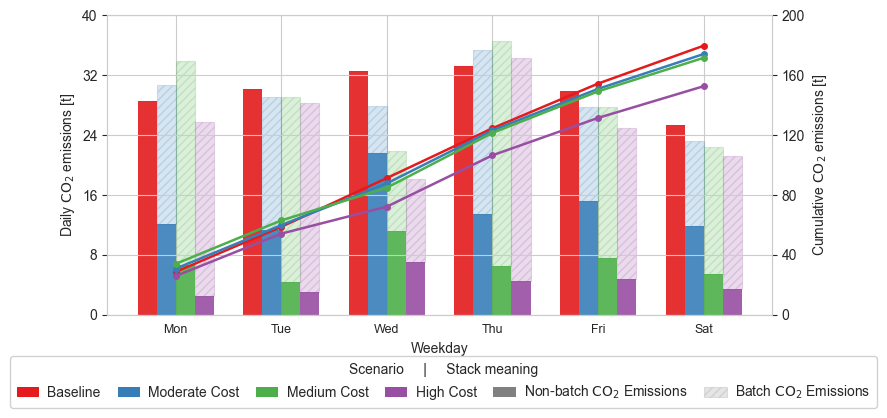

In [63]:
# =============================================================================
# Emissions: stacked bars per day + cumulative line, synced axes
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df ----------
work = df_all.copy()

# scenario from run_name prefix
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday from run_name pattern ..._ddmmyyyy_...
digits = work["run_name"].astype(str).str.extract(r"(\d{8})", expand=False)
dates = pd.to_datetime(digits, format="%d%m%Y", errors="coerce")
weekday_map = {0:"Montag", 1:"Dienstag", 2:"Mittwoch", 3:"Donnerstag", 4:"Freitag", 5:"Samstag"}
work["weekday"] = dates.dt.dayofweek.map(weekday_map)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity group
provider_active_days = {
    "dhl": {"Montag","Mittwoch","Freitag"},
    "hermes": {"Dienstag","Samstag"},
    "dpd": {"Dienstag","Freitag"},
    "gls": {"Montag","Donnerstag"},
    "ups": {"Montag","Donnerstag"},
    "amazon": {"Dienstag","Donnerstag","Samstag"},
    "fedex": {"Montag","Donnerstag"},
}
def _is_active(row):
    prov = str(row.get("provider","")).strip().lower()
    wd   = str(row.get("weekday","")).strip()
    return wd in provider_active_days.get(prov, set())

work["active_flag"]    = work.apply(_is_active, axis=1)
work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")
work.loc[work["scenario"].str.lower().str.contains("base", na=False), "activity_group"] = "Non-batch Delivery Day"

# scenario labels
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":  "Medium Cost",
    "batchhigh":    "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

# emissions column numeric
if "emissions_total" not in work.columns:
    raise RuntimeError("emissions_total missing in df_all/work")
work["emissions_total"] = pd.to_numeric(work["emissions_total"], errors="coerce").fillna(0.0)

# ---------- 2) Aggregate to pivot ----------
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday", "scenario_label", "activity_group"], dropna=False)["emissions_total"]
        .sum()
        .reset_index(name="emissions_sum")
)

all_keys = pd.MultiIndex.from_product(
    [weekday_order, sorted(work["scenario_label"].dropna().unique()),
     ["Non-batch Delivery Day", "Batch Delivery Day"]],
    names=["weekday","scenario_label","activity_group"]
)
daily = (daily.set_index(["weekday","scenario_label","activity_group"])
              .reindex(all_keys)
              .fillna(0.0)
              .reset_index())

pivot = (
    daily.pivot_table(
        index=["weekday","scenario_label"],
        columns="activity_group",
        values="emissions_sum",
        aggfunc="sum",
        fill_value=0.0
    )
    .reset_index()
    .rename(columns={
        "Non-batch Delivery Day": "Non-batch emissions",
        "Batch Delivery Day":     "Batch emissions"
    })
)

# totals and cumulative
pivot = pivot.sort_values(["scenario_label","weekday"],
                          key=lambda s: s.map({d:i for i,d in enumerate(weekday_order)}))
pivot["Total emissions"]      = pivot["Non-batch emissions"] + pivot["Batch emissions"]
pivot["Cumulative emissions"] = pivot.groupby("scenario_label")["Total emissions"].cumsum()

# --- Scale emissions down for readability ---
scale_factor = 1_000_000.0 # or 1_000_000.0 for tonnes

cols_to_scale = ["Batch emissions", "Non-batch emissions", "Total emissions", "Cumulative emissions"]
pivot[cols_to_scale] = pivot[cols_to_scale].astype(float) / scale_factor


# Fixed scenario order
scenario_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]

# Present scenarios in fixed order (filter by presence)
present_set = set(pivot["scenario_label"].unique())
scen_present = [s for s in scenario_order if s in present_set]

# Colors consistent with the same fixed order
palette = sns.color_palette("Set1", len(scen_present))
colors = dict(zip(scen_present, palette))

fig, ax1 = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Bars
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch emissions"].to_numpy()
    batch    = sub["Batch emissions"].to_numpy()
    xpos = x_pos + (i - (len(scen_present) - 1) / 2.0) * width
    base_col = colors.get(scen, (0.5, 0.5, 0.5))
    ax1.bar(xpos, nonbatch, width=width, color=base_col, alpha=0.9, edgecolor="none")
    ax1.bar(xpos, batch,    width=width, bottom=nonbatch,
            facecolor=base_col, alpha=0.2, hatch=hatch_pattern, edgecolor=base_col, linewidth=edge_lw)

# Lines
ax2 = ax1.twinx()
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    ax2.plot(x_pos, sub["Cumulative emissions"], color=colors[scen],
             linewidth=1.8, marker="o", markersize=4, label=f"{scen} cumulative")

# synced axes
ax2_min, ax2_max = 0.0, 200.0
ax1_min, ax1_max = 0.0, 40.0
ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

ax2.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax2_ticks = ax2.get_yticks()
tick_fracs = (ax2_ticks - ax2_min) / max(ax2_max - ax2_min, 1e-12)
ax1.set_yticks(ax1_min + tick_fracs * (ax1_max - ax1_min))

# formatters
fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# grid and labels
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)
ax1.set_xlabel("Weekday", fontsize=10)
ax1.set_ylabel(r"Daily $\mathrm{CO_2}$ emissions [t]", fontsize=10)
ax2.set_ylabel(r"Cumulative $\mathrm{CO_2}$ emissions [t]", fontsize=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=9)

# legend
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch $\mathrm{CO_2}$ Emissions"),
    Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch $\mathrm{CO_2}$ Emissions"),
]
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=len(handles), frameon=True, fancybox=True, framealpha=0.9,
           title="Scenario     |     Stack meaning",
           handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("emissions_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()
